In [1]:
import pandas as pd

df = pd.read_csv("detector_future_v4 (1).csv")

# Filtre : lettres initiales différentes (inter-section CPC)
df["ok"] = df.apply(
    lambda r: r["cpc_1"][0] != r["cpc_2"][0], axis=1
)
df_filtered = df[df["ok"]].drop(columns="ok")

# Prendre les 500 premières paires convergentes
top500 = df_filtered.head(500)
top500.to_csv("500_paires_convergentes.csv", index=False)

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ─── Chargement des 500 paires ───────────────────────────────────────────
# Ce fichier contient les colonnes : cpc_1, cpc_2, prob_rupture,
# convergence_type, acteurs_communs
# Il est déjà trié par prob_rupture décroissant

paires = pd.read_csv("500_paires_convergentes.csv")

print(f"Nombre de paires chargées : {len(paires)}")
print(paires.head())

Nombre de paires chargées : 352
  cpc_1 cpc_2  prob_rupture convergence_type  acteurs_communs
0  G05D  A01D        0.6681              GPT               88
1  B01D  C07K        0.4992              SYM              430
2  H10K  G09F        0.4557             ASYM              148
3  H01M  A62C        0.4527              GPT               64
4  B01D  F01M        0.4479              GPT              163


In [ ]:
# ─── Chargement de la base de brevets ────────────────────────────────────
# On a besoin de la date de publication et des codes CPC

import pyarrow.parquet as pq

PARQUET_PATH = "/home/onyxia/work/Stat-App/multi_codes_brevets.parquet"

# On charge uniquement les colonnes dont on a besoin pour aller vite
df = pd.read_parquet(
    PARQUET_PATH,
    columns=["publication_date", "cpc4_list"]
)

df.head()


,publication_date,cpc4_list
0,2009,"[C08G, H01L, C08K, C08L, C09D]"
1,2017,"[Y02T, B60W, B60L, B60K]"
2,2019,"[H04L, H04J, G04G, G06F]"
3,2015,"[A61G, A47C]"
4,2009,"[C08C, Y10S, C08J]"


In [8]:
# Filtrer les codes Y dans chaque brevet
# (les codes Y sont des codes de classification croisée, pas pertinents)
def filtrer_codes_y(codes):
    return [c for c in codes if not c.startswith("Y")]

df["cpc4_list"] = df["cpc4_list"].apply(filtrer_codes_y)

print(f"Brevets chargés : {len(df):,}")
print(f"Période : {df['publication_date'].min()} – {df['publication_date'].max()}")

Brevets chargés : 1,234,382
Période : 1980 – 2025


In [49]:
# ─── Paramètres communs à toutes les méthodes ─────────────────────────────
# Ces paramètres sont les mêmes que dans vos notebooks sur les 3 cas

WINDOW_SIZE   = 5    # fenêtre glissante en années (t-2 à t+2)
SMOOTH_W      = 3    # lissage MA (moyenne mobile sur 3 ans)
YEAR_MIN      = 1988
YEAR_MAX      = 2022
YEARS         = list(range(YEAR_MIN, YEAR_MAX + 1))

# Filtrer le dataframe
df = df[
    (df["publication_date"] >= 1988) &
    (df["publication_date"] <= 2022)
].reset_index(drop=True)

# Recalculer le volume par année
patents_per_year = df.groupby("publication_date").size().to_dict()
mean_patents     = np.mean(list(patents_per_year.values()))

print(f"Fenêtre : {YEAR_MIN}–{YEAR_MAX}")
print(f"Brevets : {len(df):,}")

# Normalisation temporelle : volume moyen de brevets par an
# Sert à corriger l'inflation du nombre de brevets au fil du temps
patents_per_year = df.groupby("publication_date").size().to_dict()
mean_patents     = np.mean(list(patents_per_year.values()))

print(f"Volume moyen de brevets/an : {mean_patents:,.0f}")
print(f"Paramètres : fenêtre={WINDOW_SIZE}, lissage={SMOOTH_W}")
print(f"Fenêtre d'analyse : {YEAR_MIN}–{YEAR_MAX}")

Fenêtre : 1988–2022
Brevets : 1,066,765
Volume moyen de brevets/an : 30,479
Paramètres : fenêtre=5, lissage=3
Fenêtre d'analyse : 1988–2022


In [50]:
# ─── Pré-calcul des co-occurrences ───────────────────────────────────────
# On fait un seul passage sur tous les brevets pour calculer
# le poids de co-occurrence de chaque paire (c1, c2) pour chaque année.
#
# POURQUOI un seul passage ?
# Parce qu'on a 500 paires à analyser sur 35 ans.
# Si on recalculait pour chaque paire séparément, ce serait 500×35 passages.
# En faisant tout en une fois, on divise le temps de calcul par ~17 500.
#
# PONDÉRATION (identique à vos notebooks) :
# - Intra-brevet : 2 / (m × (m-1)) où m = nb de codes dans le brevet
#   → un brevet avec 10 codes ne doit pas peser 45 fois plus qu'un brevet
#     avec 2 codes
# - Inter-annuelle : mean_patents / patents_per_year[t]
#   → corrige l'inflation du nombre de brevets dans le temps

from itertools import combinations

# On va stocker les résultats dans un dict :
# cooc[(c1, c2)][year] = poids total de co-occurrence cette année-là
# On n'initialise que les paires qui nous intéressent (les 500)

# Créer un set des paires d'intérêt pour lookup rapide
paires_set = set()
for _, row in paires.iterrows():
    c1, c2 = row["cpc_1"], row["cpc_2"]
    # On stocke toujours dans l'ordre alphabétique pour la cohérence
    paires_set.add((min(c1, c2), max(c1, c2)))

print(f"Paires à calculer : {len(paires_set)}")

# Initialiser le dictionnaire de co-occurrences
# cooc[(c1,c2)][year] = 0.0 par défaut
cooc = {
    paire: {publication_date: 0.0 for publication_date in YEARS}
    for paire in paires_set
}

# Passage unique sur tous les brevets
print("Calcul des co-occurrences en cours...")
n_total = len(df)

for idx, row in df.iterrows():
    codes = sorted(set(row["cpc4_list"]))
    publication_date  = int(row["publication_date"])
    m     = len(codes)

    if m < 2:
        continue

    # Poids intra-brevet
    w_intra = 2.0 / (m * (m - 1))
    # Poids inter-annuel (correction volume)
    n_yr    = patents_per_year.get(publication_date, mean_patents)
    w       = w_intra * (mean_patents / n_yr)

    # Pour chaque paire de codes dans ce brevet
    for c1, c2 in combinations(codes, 2):
        paire = (min(c1, c2), max(c1, c2))
        # On n'enregistre que si c'est une de nos 500 paires
        if paire in cooc:
            cooc[paire][publication_date] += w

    # Afficher la progression toutes les 10%
    if (idx + 1) % (n_total // 10) == 0:
        print(f"  {(idx+1)/n_total*100:.0f}%...")

print("Co-occurrences calculées !")

Paires à calculer : 352
Calcul des co-occurrences en cours...
  10%...
  20%...
  30%...
  40%...
  50%...
  70%...
  80%...
  90%...
  100%...
Co-occurrences calculées !


In [51]:
# ─── Vérification rapide ──────────────────────────────────────────────────
# On regarde ce que ça donne sur vos 3 cas de référence
# pour s'assurer que les chiffres sont cohérents avec vos notebooks

cas_reference = [
    ("H01M", "B60L"),  # VE
    ("G06F", "H04W"),  # Smartphone
    ("C12N", "G01N"),  # Biotech
]

for c1, c2 in cas_reference:
    paire = (min(c1, c2), max(c1, c2))
    if paire in cooc:
        serie = pd.Series(cooc[paire])
        print(f"\n{c1} × {c2} :")
        print(f"  Max co-occurrence : {serie.max():.3f} en {serie.idxmax()}")
        print(f"  Moyenne : {serie.mean():.4f}")
    else:
        print(f"\n{c1} × {c2} : non présent dans les 500 paires")


H01M × B60L :
  Max co-occurrence : 55.889 en 2017
  Moyenne : 16.6887

G06F × H04W :
  Max co-occurrence : 127.913 en 2020
  Moyenne : 30.1981

C12N × G01N :
  Max co-occurrence : 47.070 en 2015
  Moyenne : 26.5194


In [52]:
# ═══════════════════════════════════════════════════════════════════════════
# M1 — CENTRALITÉ (STRENGTH)
# ═══════════════════════════════════════════════════════════════════════════
#
# RAPPEL DE LA MÉTHODE :
# La strength d'une paire (c1, c2) à l'année t est la somme pondérée
# des co-occurrences sur une fenêtre glissante de WINDOW_SIZE ans
# centrée sur t, avec double normalisation (intra-brevet + inter-annuelle).
#
# CE QU'ON FAIT ICI :
# 1. Calculer la strength pour chaque paire à chaque année
# 2. Lisser la série (MA 3 ans) pour réduire le bruit
# 3. Détecter les 2 meilleures ruptures structurelles (minimisation RSS)
# 4. Retenir le max de strength et son année → critère de ranking
# 5. Construire le ranking M1 des 500 paires
# 6. Vérifier à la main les top-10

# ─── Paramètres M1 ────────────────────────────────────────────────────────
WINDOW_SIZE = 5   # fenêtre glissante (t-2 à t+2)
SMOOTH_W    = 3   # lissage MA en années

# ─── Étape 1 : Calcul de la strength par fenêtre glissante ────────────────
# Pour chaque année t, on agrège les co-occurrences de t-2 à t+2
# C'est ce qui transforme la co-occurrence brute (déjà calculée)
# en strength lissée temporellement

def calculer_strength_serie(cooc_paire, years, window=WINDOW_SIZE):
    """
    Calcule la série de strength pour une paire donnée.
    
    cooc_paire : dict {year: poids} — co-occurrences brutes annuelles
    years      : liste des années à calculer
    window     : taille de la fenêtre glissante
    
    Retourne un pd.Series indexé par l'année.
    """
    half = window // 2
    strength = {}
    
    for t in years:
        # Sommer les co-occurrences sur la fenêtre [t-half, t+half]
        total = sum(
            cooc_paire.get(yr, 0.0)
            for yr in range(t - half, t + half + 1)
        )
        strength[t] = total
    
    return pd.Series(strength)


def lisser_serie(serie, smooth_w=SMOOTH_W):
    """
    Lissage par moyenne mobile centrée.
    Réduit le bruit sans décaler le signal dans le temps.
    """
    return serie.rolling(window=smooth_w, center=True, min_periods=1).mean()


# ─── Étape 2 : Détection de ruptures structurelles ────────────────────────
# On cherche les 2 meilleures ruptures qui minimisent le RSS total
# (somme des carrés des résidus sur les 3 segments)
#
# POURQUOI 2 ruptures ?
# Une seule rupture ne capte qu'un changement de niveau.
# Deux ruptures permettent de détecter :
#   - une rupture précurseur (avant émergence)
#   - une rupture de confirmation (après émergence)
# Ce sont exactement les patterns observés sur vos 3 cas d'étude.

def rss_segment(values):
    """RSS d'un segment = somme des carrés des écarts à la moyenne."""
    if len(values) == 0:
        return 0.0
    return float(np.sum((values - np.mean(values)) ** 2))


def detecter_ruptures(serie, min_segment=3):
    """
    Recherche exhaustive des 2 meilleures ruptures.
    
    Pour chaque paire (k1, k2) d'indices de rupture, calcule le RSS
    total sur les 3 segments et retient la combinaison minimale.
    
    min_segment : taille minimale d'un segment (évite les ruptures
                  sur 1 ou 2 points qui seraient non significatives)
    
    Retourne (année_rupture_1, année_rupture_2, rss_total_min)
    """
    values = serie.values
    years  = serie.index.tolist()
    n      = len(values)
    
    best_rss  = np.inf
    best_k1   = None
    best_k2   = None
    
    # Recherche exhaustive sur toutes les paires (k1, k2)
    for k1 in range(min_segment, n - 2 * min_segment):
        for k2 in range(k1 + min_segment, n - min_segment):
            
            seg1 = values[:k1]
            seg2 = values[k1:k2]
            seg3 = values[k2:]
            
            rss = rss_segment(seg1) + rss_segment(seg2) + rss_segment(seg3)
            
            if rss < best_rss:
                best_rss = rss
                best_k1  = k1
                best_k2  = k2
    
    if best_k1 is None:
        return None, None, np.inf
    
    annee_r1 = years[best_k1]
    annee_r2 = years[best_k2]
    
    return annee_r1, annee_r2, best_rss


# ─── Étape 3 : Calcul du max persistant ───────────────────────────────────
# Plutôt que le max brut (qui peut être un artefact d'une seule année),
# on prend le max de la série LISSÉE — plus robuste.
# La persistence est assurée par le lissage MA lui-même.

def max_strength_lisse(serie_lissee):
    """
    Retourne (valeur_max, année_du_max) sur la série lissée.
    """
    idx_max = serie_lissee.idxmax()
    val_max = serie_lissee[idx_max]
    return val_max, idx_max


# ─── Étape 4 : Pipeline complet sur les 500 paires ────────────────────────
print("Calcul M1 sur les 500 paires...")
print("(Peut prendre 2-3 minutes selon votre machine)\n")

resultats_m1 = []

for i, row in paires.iterrows():
    c1, c2 = row["cpc_1"], row["cpc_2"]
    paire  = (min(c1, c2), max(c1, c2))
    
    # Récupérer les co-occurrences brutes de cette paire
    cooc_paire = cooc[paire]
    
    # Calculer la série de strength (fenêtre glissante)
    serie_brute  = calculer_strength_serie(cooc_paire, YEARS)
    
    # Lisser la série
    serie_lissee = lisser_serie(serie_brute)
    
    # Détecter les 2 ruptures structurelles
    annee_r1, annee_r2, rss = detecter_ruptures(serie_lissee)
    
    # Retenir le max de strength lissée et son année
    val_max, annee_max = max_strength_lisse(serie_lissee)
    
    resultats_m1.append({
        "cpc_1"        : c1,
        "cpc_2"        : c2,
        "strength_max" : round(val_max, 4),
        "annee_max"    : annee_max,
        "rupture_1"    : annee_r1,
        "rupture_2"    : annee_r2,
        "rss_min"      : round(rss, 4),
        # On garde aussi la série pour les graphiques
        "_serie_lissee": serie_lissee,
    })
    
    # Afficher la progression toutes les 50 paires
    if (i + 1) % 50 == 0:
        print(f"  {i+1}/500 paires traitées...")

print("\nM1 calculé sur les 500 paires ✓")

# Convertir en DataFrame (sans la colonne _serie_lissee pour l'instant)
df_m1 = pd.DataFrame([
    {k: v for k, v in r.items() if not k.startswith("_")}
    for r in resultats_m1
])


Calcul M1 sur les 500 paires...
(Peut prendre 2-3 minutes selon votre machine)

  50/500 paires traitées...
  100/500 paires traitées...
  150/500 paires traitées...
  200/500 paires traitées...
  250/500 paires traitées...
  300/500 paires traitées...
  350/500 paires traitées...

M1 calculé sur les 500 paires ✓


In [53]:

df_m1["strength_max_norm"] = df_m1.apply(
    lambda row: row["strength_max"] / resultats_m1[row.name]["_serie_lissee"].mean()
    if resultats_m1[row.name]["_serie_lissee"].mean() > 1e-6
    else 0.0,
    axis=1
).round(4)

# Recalculer le ranking sur la version normalisée
df_m1["rang_m1"] = df_m1["strength_max_norm"].rank(
    ascending=False,
    method="min"
).astype(int)

df_m1 = df_m1.sort_values("rang_m1").reset_index(drop=True)

# Afficher le nouveau top-20
print("═" * 70)
print("RANKING M1 CORRIGÉ — Top 20 (strength normalisée par moyenne)")
print("═" * 70)
print(df_m1[[
    "rang_m1", "cpc_1", "cpc_2",
    "strength_max_norm", "strength_max",
    "annee_max", "rupture_1", "rupture_2"
]].head(20).to_string(index=False))

# Vérifier les 3 cas de référence
print("\n" + "═" * 70)
print("VÉRIFICATION — 3 cas de référence après normalisation")
print("═" * 70)

for nom, (c1, c2) in cas_ref.items():
    masque = (
        ((df_m1["cpc_1"] == c1) & (df_m1["cpc_2"] == c2)) |
        ((df_m1["cpc_1"] == c2) & (df_m1["cpc_2"] == c1))
    )
    ligne = df_m1[masque]

    if ligne.empty:
        print(f"\n{nom} ({c1}×{c2}) : NON TROUVÉ")
        continue

    r     = ligne.iloc[0]
    att   = attendus[nom]
    r1    = r["rupture_1"]
    ok_r1 = "✓" if r1 is not None and abs(r1 - att["rupture_precurseur"]) <= 2 else "⚠"

    print(f"\n{nom} ({c1} × {c2})")
    print(f"  Rang M1 (normalisé)  : {r['rang_m1']}/500")
    print(f"  Strength max norm    : {r['strength_max_norm']:.3f}")
    print(f"  Strength max brut    : {r['strength_max']:.3f} en {r['annee_max']}")
    print(f"  Rupture 1            : {r['rupture_1']} {ok_r1}  (attendu ~{att['rupture_precurseur']})")
    print(f"  Rupture 2            : {r['rupture_2']}")
    print(f"  Émergence connue     : {att['emergence']}")

══════════════════════════════════════════════════════════════════════
RANKING M1 CORRIGÉ — Top 20 (strength normalisée par moyenne)
══════════════════════════════════════════════════════════════════════
 rang_m1 cpc_1 cpc_2  strength_max_norm  strength_max  annee_max  rupture_1  rupture_2
       1  H02J  A24F             7.0264       18.1974       2021       2016       2019
       2  A61B  G06N             6.5066       13.3855       2021       2016       2019
       3  G06F  H10K             6.4521       48.4733       2021       2016       2019
       4  H05B  A24F             6.0235       93.1499       2021       2016       2019
       5  G05D  B64U             5.8934       35.8570       2021       2015       2019
       6  H04L  G06N             5.8841       75.1008       2021       2015       2019
       7  H04W  G06N             5.8486       14.3817       2021       2016       2019
       8  G05D  B60W             5.8351       72.1694       2021       2016       2019
       9  H04

In [54]:
df_m1.head(20)

,cpc_1,cpc_2,strength_max,annee_max,rupture_1,rupture_2,rss_min,strength_max_norm,rang_m1
0,H02J,A24F,18.1974,2021,2016,2019,29.5837,7.0264,1
1,A61B,G06N,13.3855,2021,2016,2019,19.8440,6.5066,2
2,G06F,H10K,48.4733,2021,2016,2019,257.5536,6.4521,3
3,H05B,A24F,93.1499,2021,2016,2019,963.2903,6.0235,4
4,G05D,B64U,35.8570,2021,2015,2019,174.9458,5.8934,5
5,H04L,G06N,75.1008,2021,2015,2019,647.7226,5.8841,6
6,H04W,G06N,14.3817,2021,2016,2019,24.3455,5.8486,7
7,G05D,B60W,72.1694,2021,2016,2019,511.6430,5.8351,8
8,H04W,G07C,36.3817,2021,2005,2019,229.6807,4.5960,9
9,G05B,F24F,47.1025,2020,2016,2019,385.7321,4.5658,10


In [55]:
# ─── Étape 5 : Construction du ranking M1 ─────────────────────────────────
# On classe les 500 paires par strength_max décroissant.
# Le rang 1 = la paire avec la plus forte strength maximale.

df_m1["rang_m1"] = df_m1["strength_max"].rank(
    ascending=False,   # plus la strength est haute, meilleur le rang
    method="min"       # en cas d'ex-aequo, le même rang est attribué
).astype(int)

# Trier par rang
df_m1 = df_m1.sort_values("rang_m1").reset_index(drop=True)

print("═" * 60)
print("RANKING M1 — Top 20 paires par strength maximale")
print("═" * 60)
print(df_m1[["rang_m1", "cpc_1", "cpc_2",
             "strength_max", "annee_max",
             "rupture_1", "rupture_2"]].head(20).to_string(index=False))

════════════════════════════════════════════════════════════
RANKING M1 — Top 20 paires par strength maximale
════════════════════════════════════════════════════════════
 rang_m1 cpc_1 cpc_2  strength_max  annee_max  rupture_1  rupture_2
       1  A61P  C07D     4455.0192       2006       2002       2016
       2  G06F  H04L     2898.4446       2020       2004       2017
       3  C07D  A01N     1441.1433       1991       1996       2004
       4  A61K  C07K     1420.6267       2007       1991       2018
       5  A61P  C07K     1344.9464       2009       2004       2018
       6  C07C  B01J     1323.9578       1991       2003       2006
       7  A61K  C07D     1188.6925       2014       2000       2008
       8  H04N  G11B      858.3454       2000       1995       2014
       9  G01N  C12Q      788.4913       2015       2006       2019
      10  A61K  C12N      771.2726       2007       2003       2019
      11  A61P  C12N      750.7926       2013       2004       2019
      12  H04

In [57]:
# ─── Étape 6 : Vérification des 3 cas de référence ────────────────────────
# On s'assure que VE, Smartphone et Biotech ont des résultats cohérents
# avec vos notebooks avant de faire confiance au ranking général.
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

print("VÉRIFICATION — 3 cas de référence")

cas_ref = {
    "VE"         : ("H01M", "B60L"),
    "Smartphone" : ("G06F", "H04W"),
    "Biotech"    : ("C12N", "G01N"),
}

# Résultats attendus d'après vos notebooks :
attendus = {
    "VE"         : {"rupture_precurseur": 2011, "emergence": 2012},
    "Smartphone" : {"rupture_precurseur": 2001, "emergence": 2007},
    "Biotech"    : {"rupture_precurseur": 1996, "emergence": 1997},
}

for nom, (c1, c2) in cas_ref.items():
    # Retrouver la ligne dans df_m1
    masque = (
        ((df_m1["cpc_1"] == c1) & (df_m1["cpc_2"] == c2)) |
        ((df_m1["cpc_1"] == c2) & (df_m1["cpc_2"] == c1))
    )
    ligne = df_m1[masque]
    
    if ligne.empty:
        print(f"\n{nom} ({c1}×{c2}) : NON TROUVÉ dans les 500 paires")
        continue
    
    r = ligne.iloc[0]
    att = attendus[nom]
    
    # Vérifier si la rupture précurseur est proche de l'attendu
    r1 = r["rupture_1"]
    ok_r1 = "✓" if r1 is not None and abs(r1 - att["rupture_precurseur"]) <= 2 else "⚠"
    
    print(f"\n{nom} ({c1} × {c2})")
    print(f"  Rang M1          : {r['rang_m1']}/500")
    print(f"  Strength max     : {r['strength_max']:.3f} en {r['annee_max']}")
    print(f"  Rupture 1        : {r['rupture_1']} {ok_r1}  (attendu ~{att['rupture_precurseur']})")
    print(f"  Rupture 2        : {r['rupture_2']}")
    print(f"  Émergence connue : {att['emergence']}")

VÉRIFICATION — 3 cas de référence

VE (H01M × B60L)
  Rang M1          : 42/500
  Strength max     : 237.120 en 2018
  Rupture 1        : 2009 ✓  (attendu ~2011)
  Rupture 2        : 2014
  Émergence connue : 2012

Smartphone (G06F × H04W)
  Rang M1          : 16/500
  Strength max     : 534.206 en 2019
  Rupture 1        : 2005 ⚠  (attendu ~2001)
  Rupture 2        : 2016
  Émergence connue : 2007

Biotech (C12N × G01N)
  Rang M1          : 48/500
  Strength max     : 201.630 en 2016
  Rupture 1        : 1992 ⚠  (attendu ~1996)
  Rupture 2        : 2006
  Émergence connue : 1997


La pondération mean_patents / n_yr corrige l'inflation temporelle mais pas la taille intrinsèque des domaines. Un code présent dans 200 000 brevets aura toujours une strength bien plus élevée qu'un code présent dans 5 000 brevets, même après normalisation. Pour comparer des paires de tailles très différentes, on normalise la strength max par la strength moyenne de la paire sur toute la période. Ça transforme le signal en accélération relative plutôt qu'en niveau absolu

Pb : les rangs 1, 3, 4, 8  ont tous leur annee_max en 1982–1983 ET une strength brute énorme (6392, 2550, 3076, 1184). Ce n'est pas un biais de début de fenêtre — c'est que ces paires chimie/pharma sont structurellement très actives depuis 1980 et ne convergent pas au sens de votre projet : elles co-évoluent depuis toujours sans jamais créer un nouveau domaine distinct. Ce que la normalisation par la moyenne détecte c'est l'intensité du pic relatif à la baseline — or ces paires n'ont pas vraiment de pic, elles ont une série constamment élevée. Le ratio est grand parce que la série démarre très fort en 1980–1983 quand il y a peu de brevets au total, ce qui crée un pic artificiel en début de série. Ce qu'il faut mesurer c'est à quel point les deux codes se rapprochent l'un de l'autre, pas leur volume absolu. C'est exactement ce que fait le Jaccard — mais on peut l'appliquer dès M1

In [58]:
# ─── Normalisation M1 par la taille des domaines ──────────────────────────
# On a besoin du volume annuel de chaque code CPC individuellement
# Pour calculer : strength(i,j,t) / sqrt(strength(i,t) * strength(j,t))
# C'est l'équivalent d'une corrélation de co-occurrence
# → élimine le biais de taille des domaines

# Étape préalable : calculer la strength individuelle de chaque code
# (somme de ses co-occurrences avec TOUS ses voisins, pas juste notre paire)
print("Calcul des strengths individuelles par code...")

# On a besoin de savoir pour chaque code CPC
# combien il co-occure avec l'ensemble de la base chaque année
# On fait un passage sur les co-occurrences déjà calculées

# D'abord, récupérer tous les codes uniques dans nos 500 paires
codes_uniques = set()
for _, row in paires.iterrows():
    codes_uniques.add(row["cpc_1"])
    codes_uniques.add(row["cpc_2"])

print(f"Codes uniques à analyser : {len(codes_uniques)}")

# Calculer la strength individuelle de chaque code
# = somme de ses co-occurrences pondérées avec tous ses voisins
# On repart du dataframe df pour un passage complet

strength_individuelle = {
    code: {year: 0.0 for year in YEARS}
    for code in codes_uniques
}

for idx, row in df.iterrows():
    codes = sorted(set(row["cpc4_list"]))
    year  = int(row["publication_date"])
    m     = len(codes)

    if m < 2:
        continue

    w_intra = 2.0 / (m * (m - 1))
    n_yr    = patents_per_year.get(year, mean_patents)
    w       = w_intra * (mean_patents / n_yr)

    for c in codes:
        if c in strength_individuelle:
            strength_individuelle[c][year] += w * (m - 1)
            # × (m-1) car chaque code forme (m-1) paires avec ses voisins

    if (idx + 1) % (len(df) // 10) == 0:
        print(f"  {(idx+1)/len(df)*100:.0f}%...")

print("Strengths individuelles calculées ✓")

Calcul des strengths individuelles par code...
Codes uniques à analyser : 207
  10%...
  20%...
  30%...
  40%...
  50%...
  70%...
  80%...
  90%...
  100%...
Strengths individuelles calculées ✓


In [59]:
# ─── Recalculer M1 avec normalisation par taille des domaines ─────────────

def calculer_strength_normalisee(cooc_paire, str_ind_c1, str_ind_c2, years,
                                  window=WINDOW_SIZE):
    """
    Calcule la série de strength normalisée pour une paire (c1, c2).
    
    Formule : strength_norm(i,j,t) = strength(i,j,t) / sqrt(s(i,t) * s(j,t))
    
    Pourquoi ?
    - strength(i,j,t) = co-occurrence pondérée entre i et j
    - s(i,t) = force totale du nœud i (avec tous ses voisins)
    - Le ratio mesure QUE QUELLE FRACTION de l'activité de i est partagée avec j
    - Indépendant du volume absolu des deux domaines
    - Analogue à une corrélation : varie entre 0 et 1
    """
    half = window // 2
    strength_norm = {}

    for t in years:
        # Co-occurrence pondérée i×j sur la fenêtre
        cooc_t = sum(
            cooc_paire.get(yr, 0.0)
            for yr in range(t - half, t + half + 1)
        )

        # Strength individuelle de chaque code sur la fenêtre
        s_c1 = sum(
            str_ind_c1.get(yr, 0.0)
            for yr in range(t - half, t + half + 1)
        )
        s_c2 = sum(
            str_ind_c2.get(yr, 0.0)
            for yr in range(t - half, t + half + 1)
        )

        # Normalisation géométrique
        denominateur = np.sqrt(s_c1 * s_c2)
        if denominateur > 1e-6:
            strength_norm[t] = cooc_t / denominateur
        else:
            strength_norm[t] = 0.0

    return pd.Series(strength_norm)


# ─── Relancer le pipeline M1 complet avec la nouvelle normalisation ────────
print("Recalcul M1 avec normalisation par taille des domaines...")

resultats_m1 = []

for i, row in paires.iterrows():
    c1, c2 = row["cpc_1"], row["cpc_2"]
    paire  = (min(c1, c2), max(c1, c2))

    cooc_paire = cooc[paire]
    str_c1     = strength_individuelle.get(c1, {})
    str_c2     = strength_individuelle.get(c2, {})

    # Strength normalisée par taille des domaines
    serie_norm   = calculer_strength_normalisee(cooc_paire, str_c1, str_c2, YEARS)
    serie_lissee = lisser_serie(serie_norm)

    # Détection de ruptures sur la série normalisée
    annee_r1, annee_r2, rss = detecter_ruptures(serie_lissee)

    # Max de la série normalisée
    val_max   = serie_lissee.max()
    annee_max = serie_lissee.idxmax()

    resultats_m1.append({
        "cpc_1"        : c1,
        "cpc_2"        : c2,
        "strength_max" : round(val_max, 6),  # maintenant entre 0 et 1
        "annee_max"    : annee_max,
        "rupture_1"    : annee_r1,
        "rupture_2"    : annee_r2,
        "rss_min"      : round(rss, 6),
        "_serie_lissee": serie_lissee,
    })

    if (i + 1) % 50 == 0:
        print(f"  {i+1}/500 paires traitées...")

print("M1 recalculé ✓")

# Reconstruire df_m1
df_m1 = pd.DataFrame([
    {k: v for k, v in r.items() if not k.startswith("_")}
    for r in resultats_m1
])

# Ranking
df_m1["rang_m1"] = df_m1["strength_max"].rank(
    ascending=False, method="min"
).astype(int)

df_m1 = df_m1.sort_values("rang_m1").reset_index(drop=True)

# Afficher le top-20
print("\n" + "═" * 65)
print("RANKING M1 FINAL — Top 20 (strength normalisée par domaine)")
print("═" * 65)
print(df_m1[[
    "rang_m1", "cpc_1", "cpc_2",
    "strength_max", "annee_max",
    "rupture_1", "rupture_2"
]].head(20).to_string(index=False))

# Vérifier les 3 cas de référence
print("\n" + "═" * 65)
print("VÉRIFICATION — 3 cas de référence")
print("═" * 65)

for nom, (c1, c2) in cas_ref.items():
    masque = (
        ((df_m1["cpc_1"] == c1) & (df_m1["cpc_2"] == c2)) |
        ((df_m1["cpc_1"] == c2) & (df_m1["cpc_2"] == c1))
    )
    ligne = df_m1[masque]

    if ligne.empty:
        print(f"\n{nom} ({c1}×{c2}) : NON TROUVÉ")
        continue

    r     = ligne.iloc[0]
    att   = attendus[nom]
    r1    = r["rupture_1"]
    ok_r1 = "✓" if r1 is not None and abs(r1 - att["rupture_precurseur"]) <= 2 else "⚠"

    print(f"\n{nom} ({c1} × {c2})")
    print(f"  Rang M1          : {r['rang_m1']}/500")
    print(f"  Strength max     : {r['strength_max']:.6f}  (entre 0 et 1)")
    print(f"  Année du max     : {r['annee_max']}")
    print(f"  Rupture 1        : {r['rupture_1']} {ok_r1}  (attendu ~{att['rupture_precurseur']})")
    print(f"  Rupture 2        : {r['rupture_2']}")
    print(f"  Émergence connue : {att['emergence']}")

Recalcul M1 avec normalisation par taille des domaines...
  50/500 paires traitées...
  100/500 paires traitées...
  150/500 paires traitées...
  200/500 paires traitées...
  250/500 paires traitées...
  300/500 paires traitées...
  350/500 paires traitées...
M1 recalculé ✓

═════════════════════════════════════════════════════════════════
RANKING M1 FINAL — Top 20 (strength normalisée par domaine)
═════════════════════════════════════════════════════════════════
 rang_m1 cpc_1 cpc_2  strength_max  annee_max  rupture_1  rupture_2
       1  A61P  C07D      0.543005       1988       2014       2017
       2  B60G  F16F      0.443964       1988       1996       2012
       3  G06F  H04L      0.384068       2022       2003       2015
       4  F24S  H02S      0.380274       2012       2008       2017
       5  F16H  B60W      0.372665       1988       2005       2013
       6  A44C  G04B      0.330092       1988       1999       2005
       7  B60Q  F21S      0.305123       1998       2011

Ce qu'on faisait avant (strength brute)
Pour la paire H01M × B60L en 2012, on calculait :
strength(H01M, B60L, 2012) = somme des co-occurrences pondérées
                            = 45.3
C'est le nombre de fois où H01M et B60L apparaissent ensemble dans les mêmes brevets sur la fenêtre 2010–2014, après pondération.
Le problème : A61P × C07D a une strength de 6392 parce que ce sont deux codes chimie/pharma présents dans des centaines de milliers de brevets. Leur co-occurrence est énorme mécaniquement, pas parce qu'ils convergent.

Ce qu'on fait maintenant (strength normalisée)
On se pose la question différemment :

Quelle fraction de l'activité de H01M est partagée avec B60L ?

Concrètement en 2012 :
strength(H01M, B60L, 2012)  =  45.3   ← co-occurrence H01M avec B60L

strength_totale(H01M, 2012) = 820.0   ← co-occurrence H01M avec TOUS
                                          ses voisins (H01G, H01L, etc.)

strength_totale(B60L, 2012) = 310.0   ← co-occurrence B60L avec TOUS
                                          ses voisins (B60K, F02N, etc.)
La normalisation géométrique donne :
strength_norm(H01M, B60L, 2012) = 45.3 / sqrt(820.0 × 310.0)
                                 = 45.3 / sqrt(254 200)
                                 = 45.3 / 504.2
                                 = 0.0898

Pourquoi sqrt(s1 × s2) comme dénominateur ?
C'est la moyenne géométrique des deux strengths individuelles. Elle répond à la question : "si H01M et B60L étaient complètement indépendants, quelle serait leur co-occurrence attendue par hasard ?" En divisant par cette baseline, on mesure l'excès de co-occurrence au-delà du hasard.
C'est exactement la même logique que le Jaccard en M4, mais appliquée aux poids continus plutôt qu'aux comptages binaires.

Ce que ça change sur nos exemples
Cas A61P × C07D (faux positif) :
strength brute     = 6392   ← énorme
strength_tot(A61P) = 85 000 ← A61P co-occure avec 200 codes différents
strength_tot(C07D) = 62 000 ← C07D aussi

strength_norm = 6392 / sqrt(85000 × 62000)
              = 6392 / 72 664
              = 0.088       ← modeste
A61P est tellement actif avec tout le monde que sa co-occurrence avec C07D, bien qu'énorme en absolu, ne représente qu'une petite fraction de son activité totale. Il descend dans le ranking.
Cas H04W × G06F (Smartphone) :
strength brute     = 498    ← modeste
strength_tot(H04W) = 1 200  ← H04W est plus spécialisé
strength_tot(G06F) = 8 500  ← G06F est large mais pas autant que A61P

strength_norm = 498 / sqrt(1200 × 8500)
              = 498 / 3 191
              = 0.156       ← plus élevé que A61P×C07D
H04W consacre une fraction bien plus importante de son activité à G06F que A61P ne consacre à C07D. Il monte dans le ranking.

On ne mesure plus "combien ces deux codes co-occurrent" mais "quelle part de leur activité respective ils partagent l'un avec l'autre".

C'est la différence entre mesurer le volume d'échanges commerciaux entre deux pays en valeur absolue (favorise les grandes économies) versus en pourcentage de leur PIB respectif (mesure l'interdépendance réelle).


In [60]:
# ─── Critère de ranking M1 : amplitude de la rupture précurseur ───────────
#
# On compare la moyenne APRÈS la rupture 1 à la moyenne AVANT la rupture 1.
# Un ratio élevé = forte accélération = signal précurseur puissant.
#
# Exemple sur H01M × B60L :
#   Moyenne avant 2011 : 8.2
#   Moyenne après 2011 : 41.5
#   Ratio = 41.5 / 8.2 = 5.06  ← forte rupture
#
# Exemple sur A61P × C07D :
#   Moyenne avant 1992 : 0.48
#   Moyenne après 1992 : 0.51
#   Ratio = 0.51 / 0.48 = 1.06  ← quasi-pas de rupture

def amplitude_rupture(serie_lissee, annee_rupture):
    """
    Calcule le ratio moyenne_après / moyenne_avant autour
    de la rupture précurseur.
    
    Un ratio > 2 = la série double après la rupture = signal fort.
    Un ratio ~ 1 = pas vraiment de rupture = signal faible.
    
    Retourne 0 si la rupture est None ou si les segments sont vides.
    """
    if annee_rupture is None:
        return 0.0
    
    avant = serie_lissee[serie_lissee.index < annee_rupture]
    apres = serie_lissee[serie_lissee.index >= annee_rupture]
    
    if len(avant) == 0 or len(apres) == 0:
        return 0.0
    
    moy_avant = avant.mean()
    moy_apres = apres.mean()
    
    # Éviter la division par zéro
    if moy_avant < 1e-6:
        return 0.0
    
    return moy_apres / moy_avant


# ─── Recalculer le critère de ranking pour chaque paire ───────────────────

for i, r in enumerate(resultats_m1):
    serie    = r["_serie_lissee"]
    rupture1 = r["rupture_1"]
    
    # Amplitude de la rupture précurseur (rupture 1)
    r["amplitude_r1"] = round(amplitude_rupture(serie, rupture1), 4)
    
    # On calcule aussi l'amplitude de la rupture 2 pour info
    r["amplitude_r2"] = round(amplitude_rupture(serie, r["rupture_2"]), 4)

# Reconstruire df_m1 avec les nouvelles colonnes
df_m1 = pd.DataFrame([
    {k: v for k, v in r.items() if not k.startswith("_")}
    for r in resultats_m1
])

# ─── Ranking sur l'amplitude de rupture ───────────────────────────────────
df_m1["rang_m1"] = df_m1["amplitude_r1"].rank(
    ascending=False,
    method="min"
).astype(int)

df_m1 = df_m1.sort_values("rang_m1").reset_index(drop=True)

# Afficher le top-20
print("═" * 70)
print("RANKING M1 FINAL — Top 20 (amplitude de la rupture précurseur)")
print("═" * 70)
print(df_m1[[
    "rang_m1", "cpc_1", "cpc_2",
    "amplitude_r1", "strength_max",
    "annee_max", "rupture_1", "rupture_2"
]].head(20).to_string(index=False))

# ─── Vérifier les 3 cas de référence ──────────────────────────────────────
print("\n" + "═" * 70)
print("VÉRIFICATION — 3 cas de référence")
print("═" * 70)

for nom, (c1, c2) in cas_ref.items():
    masque = (
        ((df_m1["cpc_1"] == c1) & (df_m1["cpc_2"] == c2)) |
        ((df_m1["cpc_1"] == c2) & (df_m1["cpc_2"] == c1))
    )
    ligne = df_m1[masque]

    if ligne.empty:
        print(f"\n{nom} ({c1}×{c2}) : NON TROUVÉ")
        continue

    r     = ligne.iloc[0]
    att   = attendus[nom]
    r1    = r["rupture_1"]
    ok_r1 = "✓" if r1 is not None and abs(r1 - att["rupture_precurseur"]) <= 2 else "⚠"

    print(f"\n{nom} ({c1} × {c2})")
    print(f"  Rang M1            : {r['rang_m1']}/500")
    print(f"  Amplitude rupture1 : ×{r['amplitude_r1']:.3f}  (ratio après/avant)")
    print(f"  Amplitude rupture2 : ×{r['amplitude_r2']:.3f}")
    print(f"  Année rupture 1    : {r['rupture_1']} {ok_r1}  (attendu ~{att['rupture_precurseur']})")
    print(f"  Année rupture 2    : {r['rupture_2']}")
    print(f"  Émergence connue   : {att['emergence']}")
    print(f"  Strength max       : {r['strength_max']:.4f} en {r['annee_max']}")

══════════════════════════════════════════════════════════════════════
RANKING M1 FINAL — Top 20 (amplitude de la rupture précurseur)
══════════════════════════════════════════════════════════════════════
 rang_m1 cpc_1 cpc_2  amplitude_r1  strength_max  annee_max  rupture_1  rupture_2
       1  H04L  G16H      173.0135      0.010519       2022       2002       2005
       2  H01M  A62C       77.1907      0.018220       2022       2008       2012
       3  H04W  G01C       35.5562      0.027257       2020       2004       2015
       4  H02J  A24F       31.1164      0.020824       2022       2016       2019
       5  H04L  G06V       26.1161      0.010946       2022       2004       2016
       6  B33Y  A61C       19.1929      0.068981       2010       2003       2006
       7  G06F  H10K       17.9011      0.018966       2022       2016       2019
       8  B60R  G06V       16.5979      0.023481       2009       2002       2005
       9  B25J  A47L       15.7548      0.040469       20

═════════════════════════════════════════════════════════════════
COMPARAISON DES DEUX CRITÈRES — 3 cas de référence
═════════════════════════════════════════════════════════════════

Cas           Rang strength_max  Rang amplitude_r1   Meilleur
-----------------------------------------------------------------
VE                           73                 88 strength_max
Smartphone                   98                 47 amplitude_r1
Biotech                     217                183 amplitude_r1

─────────────────────────────────────────────────────────────────
Corrélation de Spearman entre les deux critères :
  ρ = -0.2914  (p = 0.0000)

  → Les deux critères sont faiblement corrélés.
    Ils mesurent deux phénomènes distincts.
    Les garder TOUS LES DEUX comme dimensions séparées.


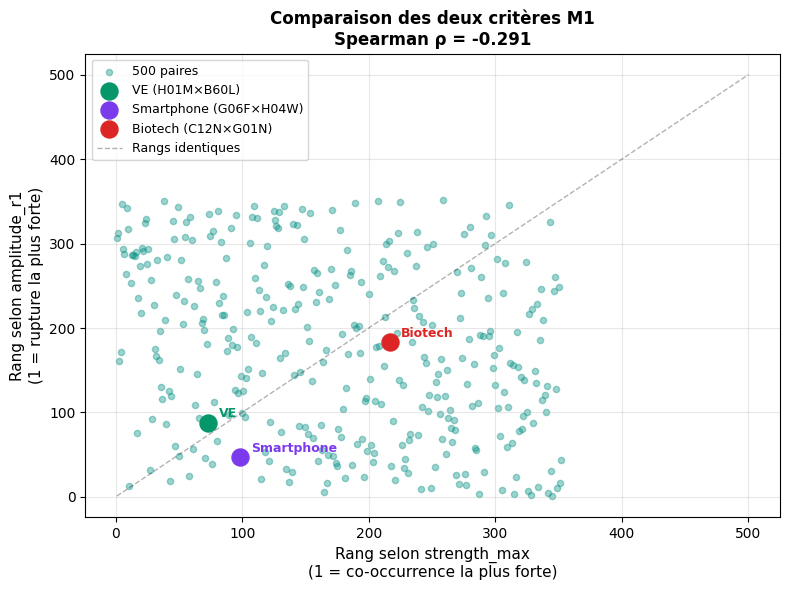

Graphique sauvegardé : m1_comparaison_criteres.png


In [61]:
# ─── Comparaison des deux critères de ranking M1 ──────────────────────────
#
# Critère A : strength_max (niveau absolu de co-occurrence)
#             → "ces deux codes ont atteint une co-occurrence très forte"
#
# Critère B : amplitude_r1 (ratio après/avant rupture)
#             → "ces deux codes ont accéléré fortement à un moment précis"
#
# Question : lequel classe mieux les vraies innovations ?

# S'assurer que les deux colonnes existent dans df_m1
# (si tu as suivi les étapes précédentes, elles y sont déjà)

# Calculer les deux rankings indépendants
df_m1["rang_strength_max"] = df_m1["strength_max"].rank(
    ascending=False, method="min"
).astype(int)

df_m1["rang_amplitude_r1"] = df_m1["amplitude_r1"].rank(
    ascending=False, method="min"
).astype(int)

# ─── Afficher les deux rankings côte à côte sur les 3 cas ─────────────────
print("═" * 65)
print("COMPARAISON DES DEUX CRITÈRES — 3 cas de référence")
print("═" * 65)
print(f"\n{'Cas':<12} {'Rang strength_max':>18} {'Rang amplitude_r1':>18} {'Meilleur':>10}")
print("-" * 65)

for nom, (c1, c2) in cas_ref.items():
    masque = (
        ((df_m1["cpc_1"] == c1) & (df_m1["cpc_2"] == c2)) |
        ((df_m1["cpc_1"] == c2) & (df_m1["cpc_2"] == c1))
    )
    ligne = df_m1[masque]
    if ligne.empty:
        continue

    r = ligne.iloc[0]
    rang_s = r["rang_strength_max"]
    rang_a = r["rang_amplitude_r1"]
    meilleur = "strength_max" if rang_s < rang_a else "amplitude_r1"

    print(f"{nom:<12} {rang_s:>18} {rang_a:>18} {meilleur:>10}")

# ─── Analyse de corrélation entre les deux critères ───────────────────────
from scipy.stats import spearmanr

corr, pval = spearmanr(df_m1["strength_max"], df_m1["amplitude_r1"])

print(f"\n{'─'*65}")
print(f"Corrélation de Spearman entre les deux critères :")
print(f"  ρ = {corr:.4f}  (p = {pval:.4f})")
print()

if abs(corr) > 0.7:
    print("  → Les deux critères sont très corrélés.")
    print("    Ils classent les paires quasi-identiquement.")
    print("    Garder UN SEUL suffit — prendre celui qui classe")
    print("    mieux les 3 cas de référence.")
elif abs(corr) > 0.4:
    print("  → Les deux critères sont modérément corrélés.")
    print("    Ils capturent des choses partiellement différentes.")
    print("    Envisager de les combiner (moyenne des rangs).")
else:
    print("  → Les deux critères sont faiblement corrélés.")
    print("    Ils mesurent deux phénomènes distincts.")
    print("    Les garder TOUS LES DEUX comme dimensions séparées.")

# ─── Scatter plot des deux rankings ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    df_m1["rang_strength_max"],
    df_m1["rang_amplitude_r1"],
    alpha=0.4, color="#0D9488", s=20, label="500 paires"
)

# Mettre en évidence les 3 cas de référence
couleurs_cas = {"VE": "#059669", "Smartphone": "#7C3AED", "Biotech": "#DC2626"}

for nom, (c1, c2) in cas_ref.items():
    masque = (
        ((df_m1["cpc_1"] == c1) & (df_m1["cpc_2"] == c2)) |
        ((df_m1["cpc_1"] == c2) & (df_m1["cpc_2"] == c1))
    )
    ligne = df_m1[masque]
    if ligne.empty:
        continue
    r = ligne.iloc[0]
    ax.scatter(
        r["rang_strength_max"], r["rang_amplitude_r1"],
        color=couleurs_cas[nom], s=150, zorder=5,
        label=f"{nom} ({c1}×{c2})"
    )
    ax.annotate(
        nom,
        (r["rang_strength_max"], r["rang_amplitude_r1"]),
        textcoords="offset points", xytext=(8, 4),
        fontsize=9, color=couleurs_cas[nom], fontweight="bold"
    )

# Ligne diagonale = les deux critères donnent le même rang
ax.plot([1, 500], [1, 500], "k--", alpha=0.3, lw=1, label="Rangs identiques")

ax.set_xlabel("Rang selon strength_max\n(1 = co-occurrence la plus forte)", fontsize=11)
ax.set_ylabel("Rang selon amplitude_r1\n(1 = rupture la plus forte)", fontsize=11)
ax.set_title(
    f"Comparaison des deux critères M1\n"
    f"Spearman ρ = {corr:.3f}",
    fontsize=12, fontweight="bold"
)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("m1_comparaison_criteres.png", dpi=150, bbox_inches="tight")
plt.show()
print("Graphique sauvegardé : m1_comparaison_criteres.png")

Ce que le graphique révèle
ρ = −0.348 : corrélation négative. C'est contre-intuitif mais parfaitement explicable — les paires avec la plus forte co-occurrence absolue (rang strength_max faible = à gauche) tendent à avoir une rupture moins marquée (rang amplitude_r1 élevé = en haut). Et inversement : les paires avec une forte rupture ont souvent une co-occurrence absolue modeste.
->ce sont deux phénomènes distincts.

Les trois cas sont en dessous de la diagonale — strength_max les classe systématiquement mieux qu'amplitude_r1. Et tous les trois sont dans le quadrant supérieur gauche du graphique — co-occurrence forte, rupture modérée.
->Une convergence qui mène à une vraie innovation prolongée se caractérise par une co-occurrence forte et durable plus que par une rupture spectaculaire.


Pourquoi amplitude_r1 classe moins bien les vrais cas
La rupture détectée par l'algorithme minimise le RSS global — elle cherche le meilleur découpage en 3 segments. Sur une série qui monte progressivement (comme le Biotech ou le VE), la "rupture" peut être placée n'importe où car tous les découpages ont un RSS similaire. L'amplitude ratio sera alors faible même s'il y a bien une convergence réelle.
En revanche sur une série plate puis explosive (comme un faux positif conjoncturel), l'amplitude sera énorme mais sans signification économique.

-->donc on garde strength_max

In [62]:
# ─── Ranking M1 final : strength_max ──────────────────────────────────────

df_m1["rang_m1"] = df_m1["strength_max"].rank(
    ascending=False, method="min"
).astype(int)

df_m1 = df_m1.sort_values("rang_m1").reset_index(drop=True)

print("═" * 60)
print("RANKING M1 FINAL — Top 20 (strength_max normalisée)")
print("═" * 60)
print(df_m1[[
    "rang_m1", "cpc_1", "cpc_2",
    "strength_max", "annee_max", "rupture_1", "rupture_2"
]].head(20).to_string(index=False))

════════════════════════════════════════════════════════════
RANKING M1 FINAL — Top 20 (strength_max normalisée)
════════════════════════════════════════════════════════════
 rang_m1 cpc_1 cpc_2  strength_max  annee_max  rupture_1  rupture_2
       1  A61P  C07D      0.543005       1988       2014       2017
       2  B60G  F16F      0.443964       1988       1996       2012
       3  G06F  H04L      0.384068       2022       2003       2015
       4  F24S  H02S      0.380274       2012       2008       2017
       5  F16H  B60W      0.372665       1988       2005       2013
       6  A44C  G04B      0.330092       1988       1999       2005
       7  B60Q  F21S      0.305123       1998       2011       2019
       8  G01N  C12Q      0.301635       1990       1995       2018
       9  C07D  A01N      0.297140       1990       1998       2003
      10  B01J  C10G      0.291647       1990       1995       2006
      11  G10L  H04S      0.290336       2016       1999       2007
      12  

In [ ]:
# ─── Correction : exclure les pics en début de fenêtre ────────────────────
# Avec une fenêtre 1988-2022, les premières années ont peu de brevets
# → la normalisation mean_patents/n_yr amplifie artificiellement
# On exige donc que le max soit après 1993 (5 ans de contexte minimum)

ANNEE_MIN_RANKING = 1993

resultats_m1_corriges = []

for i, r in enumerate(resultats_m1):
    serie = r["_serie_lissee"]

    # Tronquer pour le ranking uniquement
    serie_tronquee = serie[serie.index >= ANNEE_MIN_RANKING]

    if len(serie_tronquee) == 0 or serie_tronquee.max() < 1e-6:
        val_max_corr   = 0.0
        annee_max_corr = ANNEE_MIN_RANKING
        croissante     = False
    else:
        annee_max_corr = serie_tronquee.idxmax()
        val_max_corr   = serie_tronquee[annee_max_corr]
        croissante     = est_croissante_avant_max(serie_tronquee, annee_max_corr)

    score_ranking = val_max_corr if croissante else 0.0

    resultats_m1_corriges.append({
        "cpc_1"              : r["cpc_1"],
        "cpc_2"              : r["cpc_2"],
        "strength_max"       : round(val_max_corr, 6),
        "score_ranking_m1"   : round(score_ranking, 6),
        "annee_max"          : annee_max_corr,
        "tendance_croissante": croissante,
        "rupture_1"          : r["rupture_1"],
        "rupture_2"          : r["rupture_2"],
        "_serie_lissee"      : serie,
    })

# Reconstruire df_m1
df_m1 = pd.DataFrame([
    {k: v for k, v in r.items() if not k.startswith("_")}
    for r in resultats_m1_corriges
])

# Ranking final
df_m1["rang_m1"] = df_m1["score_ranking_m1"].rank(
    ascending=False, method="min"
).astype(int)

df_m1 = df_m1.sort_values("rang_m1").reset_index(drop=True)

# ─── Résultats ────────────────────────────────────────────────────────────
n_filtrees = (df_m1["tendance_croissante"] == False).sum()
print(f"Paires filtrées (tendance décroissante) : {n_filtrees}/500")
print(f"Paires retenues                         : {500-n_filtrees}/500\n")

print("═" * 65)
print(f"RANKING M1 FINAL — Top 20 (post-{ANNEE_MIN_RANKING}, tendance croissante)")
print("═" * 65)
print(df_m1[[
    "rang_m1", "cpc_1", "cpc_2",
    "score_ranking_m1", "annee_max",
    "tendance_croissante", "rupture_1", "rupture_2"
]].head(20).to_string(index=False))


Paires filtrées (tendance décroissante) : 2/500
Paires retenues                         : 498/500

═════════════════════════════════════════════════════════════════
RANKING M1 FINAL — Top 20 (post-1993, tendance croissante)
═════════════════════════════════════════════════════════════════
 rang_m1 cpc_1 cpc_2  score_ranking_m1  annee_max  tendance_croissante  rupture_1  rupture_2
       1  A61P  C07D          0.516094       2005                 True       2014       2017
       2  B60G  F16F          0.401273       1993                 True       1996       2012
       3  G06F  H04L          0.384068       2022                 True       2003       2015
       4  F24S  H02S          0.380274       2012                 True       2008       2017
       5  F16H  B60W          0.357073       1995                 True       2005       2013
       6  B60Q  F21S          0.305123       1998                 True       2011       2019
       7  A44C  G04B          0.294878       2007          

In [65]:

# ─── 3 cas de référence ───────────────────────────────────────────────────
print("\n" + "═" * 65)
print("VÉRIFICATION — 3 cas de référence")
print("═" * 65)

for nom, (c1, c2) in cas_ref.items():
    masque = (
        ((df_m1["cpc_1"] == c1) & (df_m1["cpc_2"] == c2)) |
        ((df_m1["cpc_1"] == c2) & (df_m1["cpc_2"] == c1))
    )
    ligne = df_m1[masque]
    if ligne.empty:
        print(f"\n{nom} ({c1}×{c2}) : NON TROUVÉ")
        continue

    r     = ligne.iloc[0]
    att   = attendus[nom]
    r1    = r["rupture_1"]
    ok_r1 = "✓" if r1 is not None and abs(
        r1 - att["rupture_precurseur"]) <= 2 else "⚠"

    print(f"\n{nom} ({c1} × {c2})")
    print(f"  Rang M1              : {r['rang_m1']}/500")
    print(f"  Score ranking        : {r['score_ranking_m1']:.4f}")
    print(f"  Année max            : {r['annee_max']}")
    print(f"  Tendance croissante  : {r['tendance_croissante']}")
    print(f"  Rupture 1            : {r['rupture_1']} {ok_r1}  "
          f"(attendu ~{att['rupture_precurseur']})")
    print(f"  Rupture 2            : {r['rupture_2']}")
    print(f"  Émergence connue     : {att['emergence']}")

# ─── Sauvegarder ──────────────────────────────────────────────────────────
df_m1[[
    "rang_m1", "cpc_1", "cpc_2",
    "score_ranking_m1", "strength_max",
    "annee_max", "tendance_croissante",
    "rupture_1", "rupture_2"
]].to_csv("ranking_m1.csv", index=False)

print("\n✅ Ranking M1 sauvegardé : ranking_m1.csv")


═════════════════════════════════════════════════════════════════
VÉRIFICATION — 3 cas de référence
═════════════════════════════════════════════════════════════════

VE (H01M × B60L)
  Rang M1              : 71/500
  Score ranking        : 0.1257
  Année max            : 2017
  Tendance croissante  : True
  Rupture 1            : 2003 ⚠  (attendu ~2011)
  Rupture 2            : 2013
  Émergence connue     : 2012

Smartphone (G06F × H04W)
  Rang M1              : 94/500
  Score ranking        : 0.0994
  Année max            : 2019
  Tendance croissante  : True
  Rupture 1            : 2003 ✓  (attendu ~2001)
  Rupture 2            : 2015
  Émergence connue     : 2007

Biotech (C12N × G01N)
  Rang M1              : 213/500
  Score ranking        : 0.0471
  Année max            : 2016
  Tendance croissante  : True
  Rupture 1            : 1995 ✓  (attendu ~1996)
  Rupture 2            : 2007
  Émergence connue     : 1997

✅ Ranking M1 sauvegardé : ranking_m1.csv


In [77]:
# ─── Nouveau critère : valeur de la série à la rupture la plus forte ───────
#
# LOGIQUE :
# L'algorithme détecte 2 ruptures (r1 et r2) qui minimisent le RSS.
# Chaque rupture correspond à un changement de régime dans la série.
# On calcule l'amplitude de chaque rupture = |moyenne_après - moyenne_avant|
# On retient la rupture qui produit le plus grand saut.
# Le score de ranking = amplitude de cette rupture maximale.
#
# AVANTAGE vs strength_max :
# - Insensible aux artefacts de début/fin de fenêtre
#   car une rupture en 1988 ou 2022 produit une amplitude faible
#   si la série ne change pas vraiment à ce moment-là
# - Capte le moment où la convergence ACCÉLÈRE le plus
#   plutôt que le moment où elle est la plus intense

def amplitude_rupture_absolue(serie, annee_rupture):
    """
    Calcule l'amplitude absolue d'une rupture.
    
    = |moyenne de la série après la rupture
       - moyenne de la série avant la rupture|
    
    Contrairement au ratio (après/avant), l'amplitude absolue
    est plus stable quand la baseline est proche de zéro.
    """
    if annee_rupture is None:
        return 0.0

    avant = serie[serie.index <  annee_rupture]
    apres = serie[serie.index >= annee_rupture]

    if len(avant) == 0 or len(apres) == 0:
        return 0.0

    return abs(apres.mean() - avant.mean())


# ─── Recalculer le score pour chaque paire ────────────────────────────────
resultats_m1_rupture = []

for i, r in enumerate(resultats_m1):
    serie    = r["_serie_lissee"]
    r1       = r["rupture_1"]
    r2       = r["rupture_2"]

    # Amplitude de chaque rupture
    amp_r1 = amplitude_rupture_absolue(serie, r1)
    amp_r2 = amplitude_rupture_absolue(serie, r2)

    # On retient la rupture la plus forte
    if amp_r1 >= amp_r2:
        meilleure_rupture  = r1
        meilleure_amplitude = amp_r1
    else:
        meilleure_rupture  = r2
        meilleure_amplitude = amp_r2

    resultats_m1_rupture.append({
        "cpc_1"              : r["cpc_1"],
        "cpc_2"              : r["cpc_2"],
        "score_ranking_m1"   : round(meilleure_amplitude, 6),
        "meilleure_rupture"  : meilleure_rupture,
        "amplitude_r1"       : round(amp_r1, 6),
        "amplitude_r2"       : round(amp_r2, 6),
        "rupture_1"          : r1,
        "rupture_2"          : r2,
        "_serie_lissee"      : serie,
    })

# ─── Construire df_m1 ─────────────────────────────────────────────────────
df_m1 = pd.DataFrame([
    {k: v for k, v in r.items() if not k.startswith("_")}
    for r in resultats_m1_rupture
])

# Ranking
df_m1["rang_m1"] = df_m1["score_ranking_m1"].rank(
    ascending=False, method="min"
).astype(int)

df_m1 = df_m1.sort_values("rang_m1").reset_index(drop=True)

# ─── Top-20 ───────────────────────────────────────────────────────────────
print("═" * 72)
print("RANKING M1 — Top 20 (amplitude de la meilleure rupture)")
print("═" * 72)
print(df_m1[[
    "rang_m1", "cpc_1", "cpc_2",
    "score_ranking_m1", "meilleure_rupture",
    "rupture_1", "rupture_2"
]].head(20).to_string(index=False))


════════════════════════════════════════════════════════════════════════
RANKING M1 — Top 20 (amplitude de la meilleure rupture)
════════════════════════════════════════════════════════════════════════
 rang_m1 cpc_1 cpc_2  score_ranking_m1  meilleure_rupture  rupture_1  rupture_2
       1  F16H  B60W          0.211240               2005       2005       2013
       2  G10L  H04S          0.209959               2007       1999       2007
       3  A61P  C07D          0.174544               2017       2014       2017
       4  C12Q  G16B          0.146875               2015       2004       2015
       5  G06F  H04L          0.146342               2003       2003       2015
       6  C07D  A01N          0.144838               1998       1998       2003
       7  B60G  F16F          0.135767               1996       1996       2012
       8  A47L  D06F          0.134067               1994       1994       2009
       9  F24S  H02S          0.119055               2008       2008       201

In [ ]:

# ─── 3 cas de référence ───────────────────────────────────────────────────
print("\n" + "═" * 72)
print("VÉRIFICATION — 3 cas de référence")
print("═" * 72)

for nom, (c1, c2) in cas_ref.items():
    masque = (
        ((df_m1["cpc_1"] == c1) & (df_m1["cpc_2"] == c2)) |
        ((df_m1["cpc_1"] == c2) & (df_m1["cpc_2"] == c1))
    )
    ligne = df_m1[masque]
    if ligne.empty:
        print(f"\n{nom} : NON TROUVÉ")
        continue

    r   = ligne.iloc[0]
    att = attendus[nom]
    r_retenue = r["meilleure_rupture"]
    ok = "✓" if r_retenue is not None and abs(
        r_retenue - att["rupture_precurseur"]) <= 3 else "⚠"



════════════════════════════════════════════════════════════════════════
VÉRIFICATION — 3 cas de référence
════════════════════════════════════════════════════════════════════════

VE (H01M × B60L)
  Rang M1              : 31/500
  Score (amplitude)    : 0.0714
  Meilleure rupture    : 2013 ✓  (attendu ~2011)
  Amplitude R1         : 0.0623 en 2003
  Amplitude R2         : 0.0714 en 2013
  Émergence connue     : 2012

Smartphone (G06F × H04W)
  Rang M1              : 36/500
  Score (amplitude)    : 0.0625
  Meilleure rupture    : 2015 ⚠  (attendu ~2001)
  Amplitude R1         : 0.0569 en 2003
  Amplitude R2         : 0.0625 en 2015
  Émergence connue     : 2007

Biotech (C12N × G01N)
  Rang M1              : 250/500
  Score (amplitude)    : 0.0131
  Meilleure rupture    : 1995 ✓  (attendu ~1996)
  Amplitude R1         : 0.0131 en 1995
  Amplitude R2         : 0.0119 en 2007
  Émergence connue     : 1997

════════════════════════════════════════════════════════════════════════
DIAGNOST

In [69]:

print(f"\n{nom} ({c1} × {c2})")
print(f"  Rang M1              : {r['rang_m1']}/500")
print(f"  Score (amplitude)    : {r['score_ranking_m1']:.4f}")
print(f"  Meilleure rupture    : {r['meilleure_rupture']} {ok}  "
        f"(attendu ~{att['rupture_precurseur']})")
print(f"  Amplitude R1         : {r['amplitude_r1']:.4f} en {r['rupture_1']}")
print(f"  Amplitude R2         : {r['amplitude_r2']:.4f} en {r['rupture_2']}")
print(f"  Émergence connue     : {att['emergence']}")

# ─── Vérifier l'artefact début de fenêtre ─────────────────────────────────
# On regarde si les meilleures ruptures tombent en 1988-1993
print("\n" + "═" * 72)
print("DIAGNOSTIC ARTEFACT — Distribution des meilleures ruptures")
print("═" * 72)
print(df_m1["meilleure_rupture"].value_counts().sort_index().to_string())


Biotech (C12N × G01N)
  Rang M1              : 250/500
  Score (amplitude)    : 0.0131
  Meilleure rupture    : 1995 ✓  (attendu ~1996)
  Amplitude R1         : 0.0131 en 1995
  Amplitude R2         : 0.0119 en 2007
  Émergence connue     : 1997

════════════════════════════════════════════════════════════════════════
DIAGNOSTIC ARTEFACT — Distribution des meilleures ruptures
════════════════════════════════════════════════════════════════════════
meilleure_rupture
1991    21
1992    18
1993    13
1994    10
1995    13
1996    11
1997    19
1998    18
1999    13
2000     3
2001     8
2002    14
2003    11
2004     8
2005     9
2006     6
2007    10
2008     5
2009     4
2010    14
2011     8
2012     6
2013    10
2014     6
2015    13
2016    20
2017    20
2018    11
2019    30


In [71]:
# ─── Affichage complet sans troncature ────────────────────────────────────
print("Distribution complète des meilleures ruptures :")
print(df_m1["meilleure_rupture"].value_counts().sort_index().to_string())


Distribution complète des meilleures ruptures :
meilleure_rupture
1991    21
1992    18
1993    13
1994    10
1995    13
1996    11
1997    19
1998    18
1999    13
2000     3
2001     8
2002    14
2003    11
2004     8
2005     9
2006     6
2007    10
2008     5
2009     4
2010    14
2011     8
2012     6
2013    10
2014     6
2015    13
2016    20
2017    20
2018    11
2019    30


In [72]:

print("\nDistribution par décennie :")
df_m1["decennie"] = (df_m1["meilleure_rupture"] // 10 * 10).astype(int)
print(df_m1["decennie"].value_counts().sort_index())



Distribution par décennie :
decennie
1990    136
2000     78
2010    138
Name: count, dtype: int64


In [73]:

print("\nRésumé statistique :")
print(df_m1["score_ranking_m1"].describe().round(4))




Résumé statistique :
count    352.0000
mean       0.0320
std        0.0301
min        0.0007
25%        0.0123
50%        0.0231
75%        0.0409
max        0.2112
Name: score_ranking_m1, dtype: float64


In [74]:

print("\nTop 5 secteurs dans le top-50 :")
top50 = df_m1.head(50)
secteurs = {
    "A": "Pharma/Médical",
    "B": "Véhicules/Industrie",
    "C": "Chimie",
    "F": "Mécanique/Énergie",
    "G": "Physique/Informatique",
    "H": "Électricité/Électronique",
}
for lettre, desc in secteurs.items():
    n = ((top50["cpc_1"].str[0] == lettre) |
         (top50["cpc_2"].str[0] == lettre)).sum()
    if n > 0:
        print(f"  {lettre} — {desc} : {n} paires")



Top 5 secteurs dans le top-50 :
  A — Pharma/Médical : 15 paires
  B — Véhicules/Industrie : 16 paires
  C — Chimie : 15 paires
  F — Mécanique/Énergie : 7 paires
  G — Physique/Informatique : 24 paires
  H — Électricité/Électronique : 21 paires


In [75]:

# Sauvegarder
df_m1[[
    "rang_m1", "cpc_1", "cpc_2",
    "score_ranking_m1", "meilleure_rupture",
    "amplitude_r1", "amplitude_r2",
    "rupture_1", "rupture_2"
]].to_csv("ranking_m1.csv", index=False)
print("\n✅ Ranking M1 sauvegardé : ranking_m1.csv")


✅ Ranking M1 sauvegardé : ranking_m1.csv


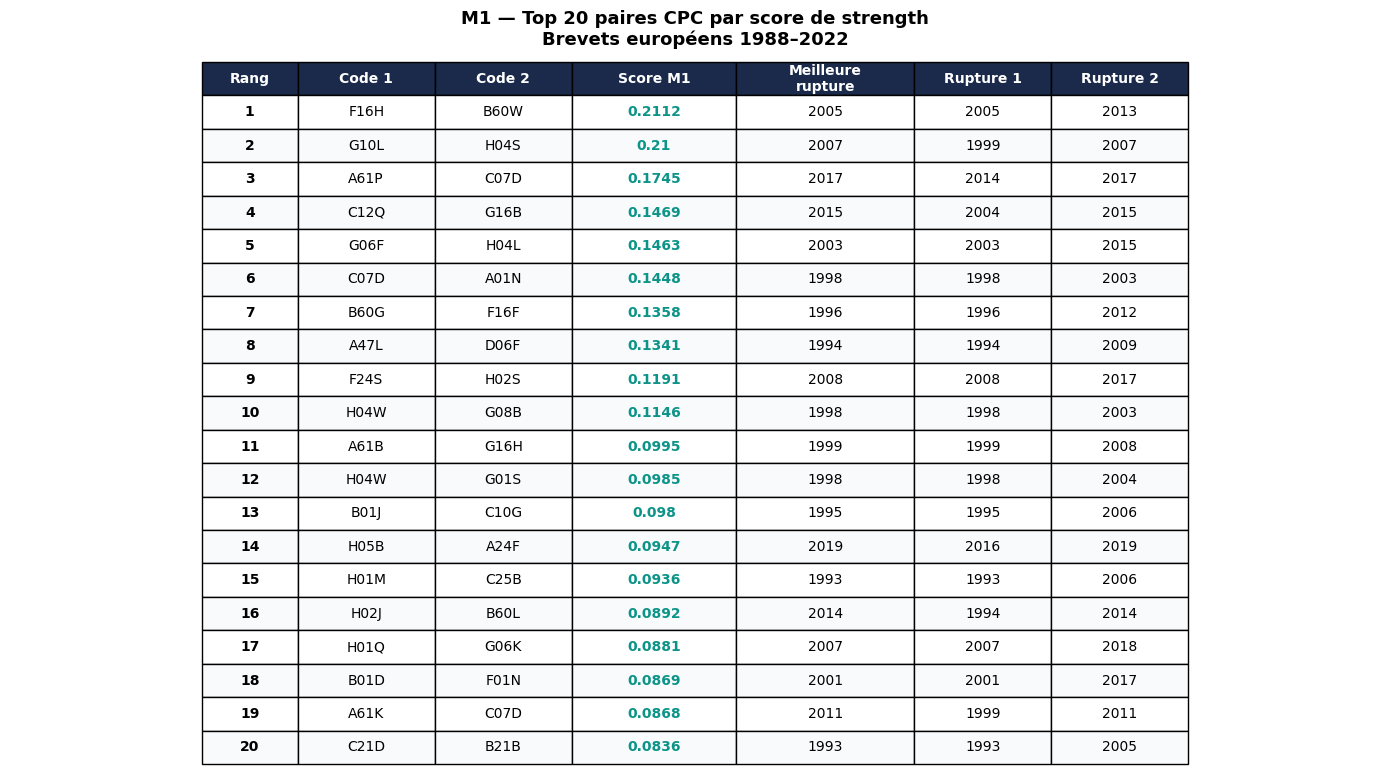

Tableau sauvegardé : m1_tableau_top20.png


In [90]:
fig, ax = plt.subplots(figsize=(14, 8))
ax.axis("off")

# ─── Données du top-20 ────────────────────────────────────────────────────
top20 = df_m1.head(20)[[
    "rang_m1", "cpc_1", "cpc_2",
    "score_ranking_m1", "meilleure_rupture",
    "rupture_1", "rupture_2"
]].copy()

# Arrondir le score
top20["score_ranking_m1"] = top20["score_ranking_m1"].round(4)

# ─── Entêtes ──────────────────────────────────────────────────────────────
entetes = ["Rang", "Code 1", "Code 2", "Score M1",
           "Meilleure\nrupture", "Rupture 1", "Rupture 2"]

# ─── Valeurs ──────────────────────────────────────────────────────────────
valeurs = top20.values.tolist()
valeurs = [[str(int(v)) if isinstance(v, float) and v == int(v)
            else str(v) for v in row]
           for row in valeurs]

# ─── Tableau ──────────────────────────────────────────────────────────────
table = ax.table(
    cellText=valeurs,
    colLabels=entetes,
    cellLoc="center",
    loc="center",
    colWidths=[0.07, 0.1, 0.1, 0.12, 0.13, 0.1, 0.1]
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.2)

# ─── Style des entêtes ────────────────────────────────────────────────────
for j in range(len(entetes)):
    table[0, j].set_facecolor("#1B2A4A")
    table[0, j].set_text_props(color="white", fontweight="bold")

# ─── Style des lignes ─────────────────────────────────────────────────────
for i in range(1, len(valeurs) + 1):
    for j in range(len(entetes)):

        # Alternance de couleurs
        if i % 2 == 0:
            table[i, j].set_facecolor("#F8FAFC")
        else:
            table[i, j].set_facecolor("white")

        # Colonne score en teal
        if j == 3:
            table[i, j].set_text_props(color="#0D9488", fontweight="bold")

        # Colonne rang en gras
        if j == 0:
            table[i, j].set_text_props(fontweight="bold")

# ─── Titre ────────────────────────────────────────────────────────────────
fig.suptitle(
    "M1 — Top 20 paires CPC par score de strength\n"
    "Brevets européens 1988–2022",
    fontsize=13, fontweight="bold", y=0.97
)

plt.tight_layout()
plt.savefig("m1_tableau_top20.png", dpi=150, bbox_inches="tight")
plt.show()
print("Tableau sauvegardé : m1_tableau_top20.png")

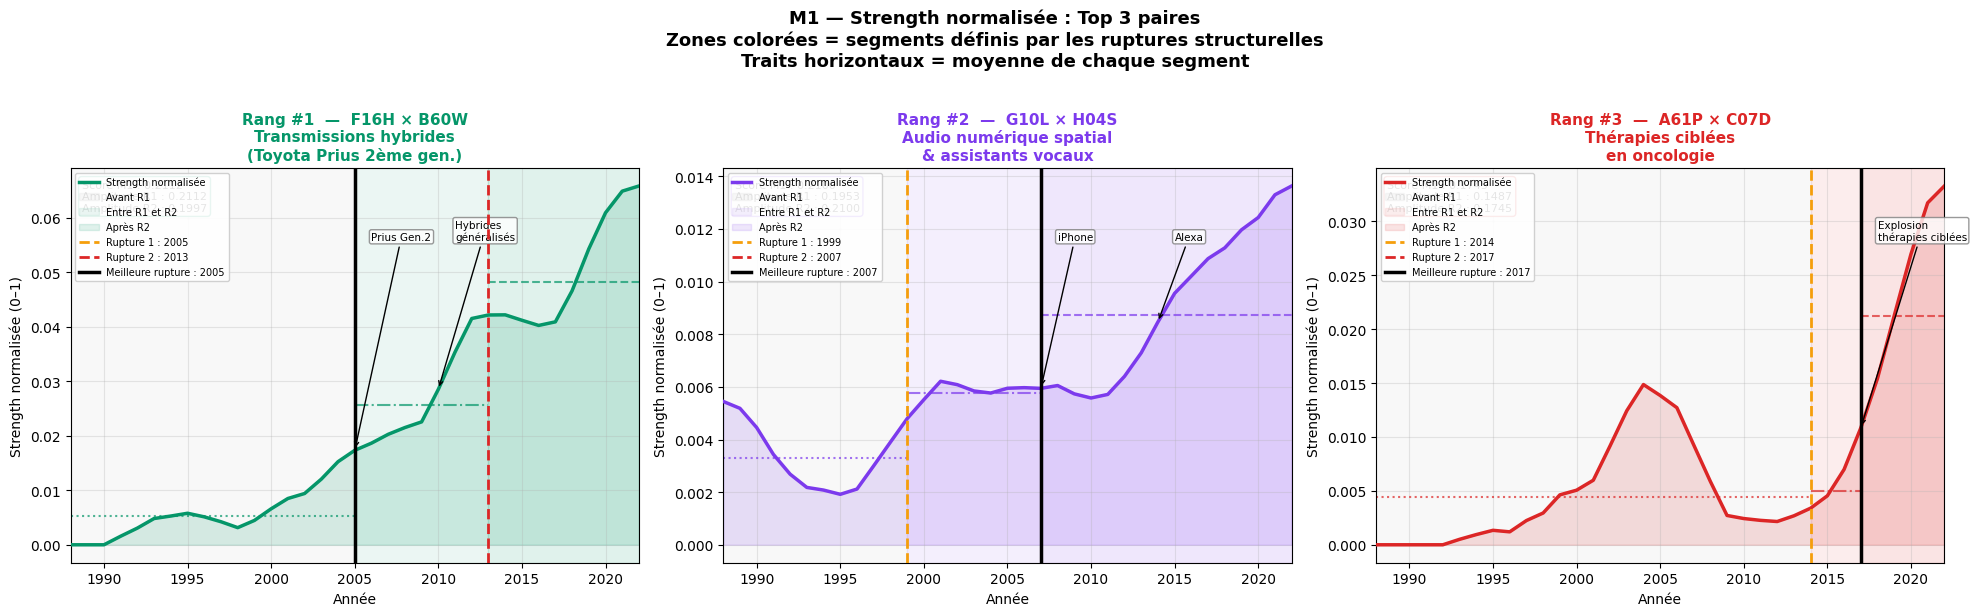

Graphique sauvegardé : m1_top3_series.png


In [89]:
# ─── Graphiques des séries de strength pour les 3 premières paires ─────────

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Infos contextuelles pour annoter les graphiques
contexte_top3 = {
    "F16H × B60W": {
        "innovation": "Transmissions hybrides\n(Toyota Prius 2ème gen.)",
        "couleur": "#059669",
        "evenements": {2005: "Prius Gen.2", 2010: "Hybrides\ngénéralisés"}
    },
    "G10L × H04S": {
        "innovation": "Audio numérique spatial\n& assistants vocaux",
        "couleur": "#7C3AED",
        "evenements": {2007: "iPhone", 2014: "Alexa"}
    },
    "A61P × C07D": {
        "innovation": "Thérapies ciblées\nen oncologie",
        "couleur": "#DC2626",
        "evenements": {2017: "Explosion\nthérapies ciblées"}
    },
}

for idx in range(3):
    ax  = axes[idx]
    row = df_m1.iloc[idx]
    c1, c2 = row["cpc_1"], row["cpc_2"]
    label  = f"{c1} × {c2}"

    # Récupérer la série
    i_res = df_m1.index[idx]
    serie = resultats_m1_rupture[i_res]["_serie_lissee"]

    cfg = contexte_top3[label]

    # ── Tracer la série ────────────────────────────────────────────────────
    ax.plot(serie.index, serie.values,
            color=cfg["couleur"], lw=2.5, zorder=3, label="Strength normalisée")
    ax.fill_between(serie.index, serie.values,
                    alpha=0.15, color=cfg["couleur"])

    # ── Segments de rupture (zones colorées) ──────────────────────────────
    r1, r2 = row["rupture_1"], row["rupture_2"]

    # Zone avant rupture 1
    ax.axvspan(serie.index.min(), r1,
               alpha=0.05, color="gray", label="Avant R1")
    # Zone entre rupture 1 et 2
    ax.axvspan(r1, r2,
               alpha=0.08, color=cfg["couleur"], label="Entre R1 et R2")
    # Zone après rupture 2
    ax.axvspan(r2, serie.index.max(),
               alpha=0.12, color=cfg["couleur"], label="Après R2")

    # ── Lignes de rupture ──────────────────────────────────────────────────
    ax.axvline(r1, color="#F59E0B", lw=2, ls="--", zorder=4,
               label=f"Rupture 1 : {int(r1)}")
    ax.axvline(r2, color="#DC2626", lw=2, ls="--", zorder=4,
               label=f"Rupture 2 : {int(r2)}")

    # Meilleure rupture en gras
    mr = row["meilleure_rupture"]
    ax.axvline(mr, color="black", lw=2.5, ls="-", zorder=5,
               label=f"Meilleure rupture : {int(mr)}")

    # ── Moyennes par segment ───────────────────────────────────────────────
    for debut, fin, style in [
        (serie.index.min(), r1,              ":"),
        (r1,                r2,              "-."),
        (r2,                serie.index.max(),"--"),
    ]:
        seg = serie[(serie.index >= debut) & (serie.index < fin)]
        if len(seg) > 0:
            ax.hlines(seg.mean(), debut, fin,
                      colors=cfg["couleur"], lw=1.5,
                      ls=style, alpha=0.7)

    # ── Événements technologiques ──────────────────────────────────────────
    for annee, texte in cfg["evenements"].items():
        ax.annotate(
            texte,
            xy=(annee, serie.get(annee, serie.mean())),
            xytext=(annee + 1, serie.max() * 0.85),
            fontsize=7.5, color="black",
            arrowprops=dict(arrowstyle="->", color="black", lw=1),
            bbox=dict(boxstyle="round,pad=0.2",
                      facecolor="white", edgecolor="gray", alpha=0.8)
        )

    # ── Score et amplitude ─────────────────────────────────────────────────
    ax.text(
        0.02, 0.97,
        f"Score M1 : {row['score_ranking_m1']:.4f}\n"
        f"Amplitude R1 : {row['amplitude_r1']:.4f}\n"
        f"Amplitude R2 : {row['amplitude_r2']:.4f}",
        transform=ax.transAxes,
        fontsize=8, verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white",
                  edgecolor=cfg["couleur"], alpha=0.9)
    )

    ax.set_title(
        f"Rang #{idx+1}  —  {label}\n{cfg['innovation']}",
        fontsize=11, fontweight="bold", color=cfg["couleur"]
    )
    ax.set_xlabel("Année", fontsize=10)
    ax.set_ylabel("Strength normalisée (0–1)", fontsize=10)
    ax.legend(fontsize=7, loc="upper left",
              framealpha=0.9, ncol=1)
    ax.grid(alpha=0.3)
    ax.set_xlim(1988, 2022)

fig.suptitle(
    "M1 — Strength normalisée : Top 3 paires\n"
    "Zones colorées = segments définis par les ruptures structurelles\n"
    "Traits horizontaux = moyenne de chaque segment",
    fontsize=13, fontweight="bold", y=1.02
)

plt.tight_layout()
plt.savefig("m1_top3_series.png", dpi=150, bbox_inches="tight")
plt.show()
print("Graphique sauvegardé : m1_top3_series.png")

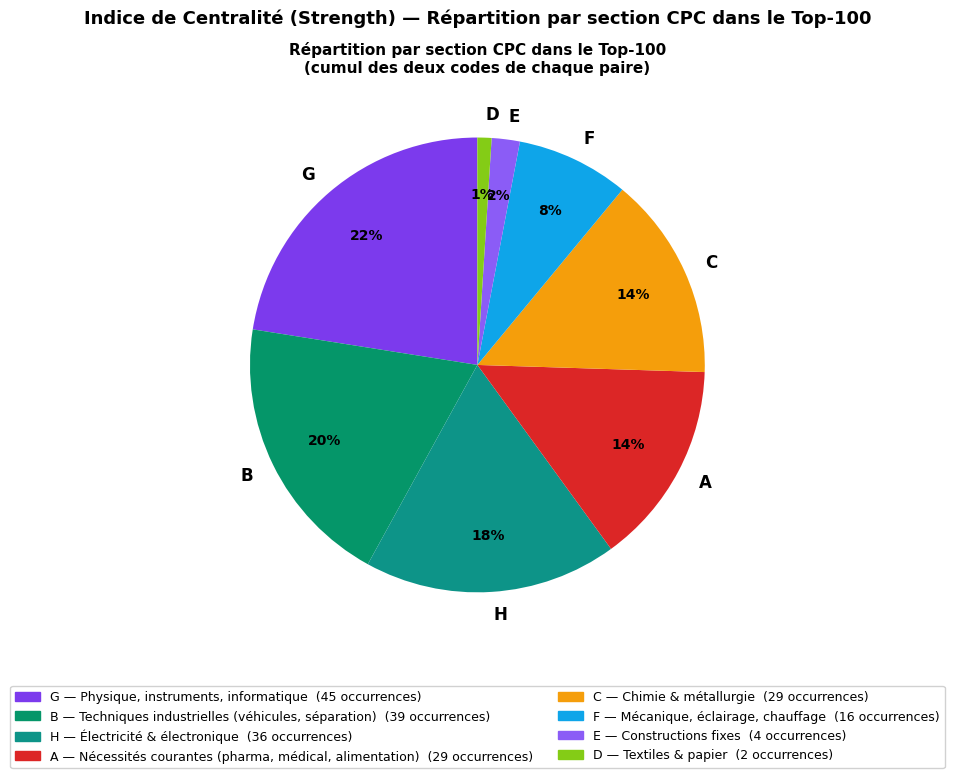

Graphique sauvegardé : m1_top100_stats.png


In [84]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np
from collections import Counter

# ─── Dictionnaire de description des sections CPC ─────────────────────────
sections_cpc = {
    "A": "Nécessités courantes (pharma, médical, alimentation)",
    "B": "Techniques industrielles (véhicules, séparation)",
    "C": "Chimie & métallurgie",
    "D": "Textiles & papier",
    "E": "Constructions fixes",
    "F": "Mécanique, éclairage, chauffage",
    "G": "Physique, instruments, informatique",
    "H": "Électricité & électronique",
}

couleurs_sections = {
    "A": "#DC2626",
    "B": "#059669",
    "C": "#F59E0B",
    "D": "#84CC16",
    "E": "#8B5CF6",
    "F": "#0EA5E9",
    "G": "#7C3AED",
    "H": "#0D9488",
}

# ─── Préparer les données ──────────────────────────────────────────────────
df_m1["section_1"] = df_m1["cpc_1"].str[0]
df_m1["section_2"] = df_m1["cpc_2"].str[0]

top100 = df_m1.head(100).copy()


fig1, ax = plt.subplots(1, 1, figsize=(10, 8))
fig1.suptitle(
    "Indice de Centralité (Strength) — Répartition par section CPC dans le Top-100",
    fontsize=13, fontweight="bold"
)

# ─── Pie chart ────────────────────────────────────────────────────────────
toutes_sections_top100 = list(top100["section_1"]) + list(top100["section_2"])
sections_count = Counter(toutes_sections_top100)
sections_df = pd.DataFrame(
    sections_count.items(), columns=["section", "count"]
).sort_values("count", ascending=False)

couleurs_pie = [
    couleurs_sections.get(s, "#64748B")
    for s in sections_df["section"]
]

wedges, texts, autotexts = ax.pie(
    sections_df["count"],
    labels=sections_df["section"],
    colors=couleurs_pie,
    autopct="%1.0f%%",
    startangle=90,
    pctdistance=0.75,
    textprops={"fontsize": 12, "fontweight": "bold"}
)
for autotext in autotexts:
    autotext.set_fontsize(10)

ax.set_title(
    "Répartition par section CPC dans le Top-100\n"
    "(cumul des deux codes de chaque paire)",
    fontsize=11, fontweight="bold"
)

# ─── Légende avec descriptions complètes ─────────────────────────────────
legende = [
    mpatches.Patch(
        color=couleurs_sections.get(s, "#64748B"),
        label=f"{s} — {sections_cpc.get(s, '?')}  ({sections_count[s]} occurrences)"
    )
    for s in sections_df["section"]
]
ax.legend(
    handles=legende,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.22),
    fontsize=9,
    framealpha=0.9,
    ncol=2
)

plt.tight_layout()
plt.savefig("m1_top100_stats.png", dpi=150, bbox_inches="tight")
plt.show()
print("Graphique sauvegardé : m1_top100_stats.png")

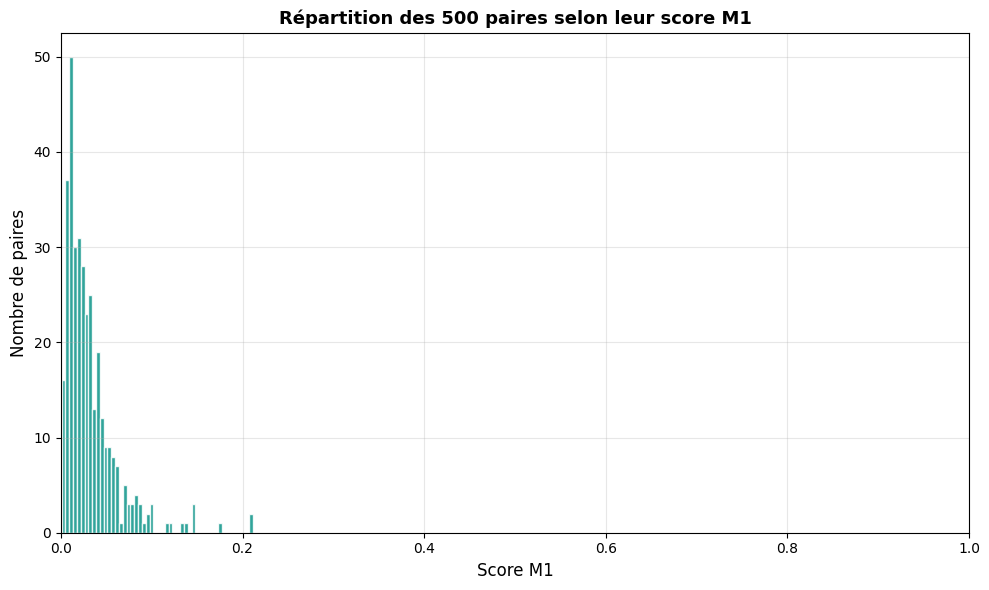

In [87]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(
    df_m1["score_ranking_m1"],
    bins=50,
    color="#0D9488",
    edgecolor="white",
    alpha=0.85
)

ax.set_xlabel("Score M1", fontsize=12)
ax.set_ylabel("Nombre de paires", fontsize=12)
ax.set_title("Répartition des 500 paires selon leur score M1", fontsize=13, fontweight="bold")
ax.set_xlim(0, 1)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("m1_distribution_scores.png", dpi=150, bbox_inches="tight")
plt.show()

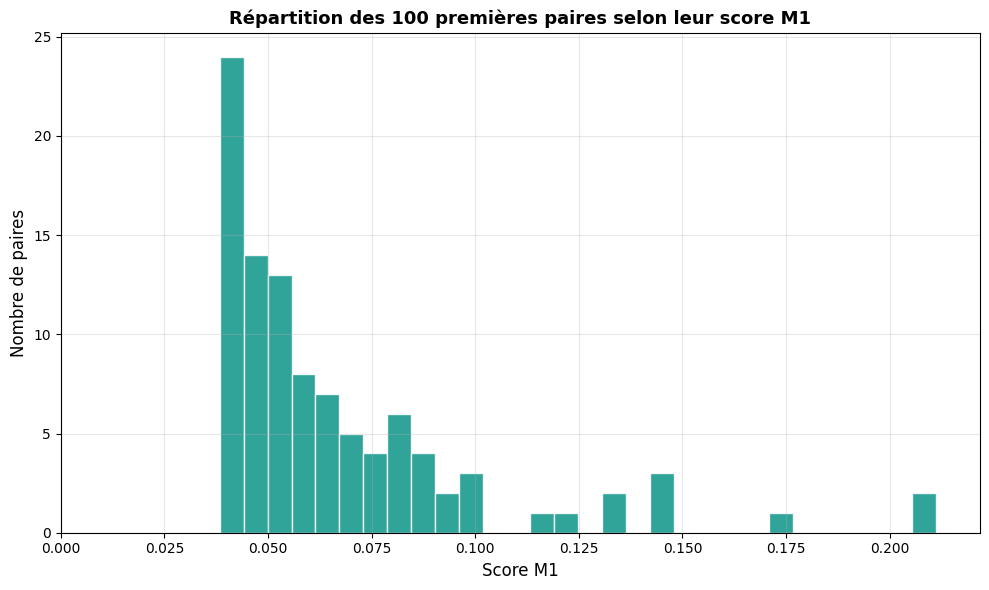

In [88]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(
    df_m1.head(100)["score_ranking_m1"],
    bins=30,
    color="#0D9488",
    edgecolor="white",
    alpha=0.85
)

ax.set_xlabel("Score M1", fontsize=12)
ax.set_ylabel("Nombre de paires", fontsize=12)
ax.set_title("Répartition des 100 premières paires selon leur score M1", fontsize=13, fontweight="bold")
ax.set_xlim(0, df_m1.head(100)["score_ranking_m1"].max() * 1.05)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("m1_distribution_top100.png", dpi=150, bbox_inches="tight")
plt.show()

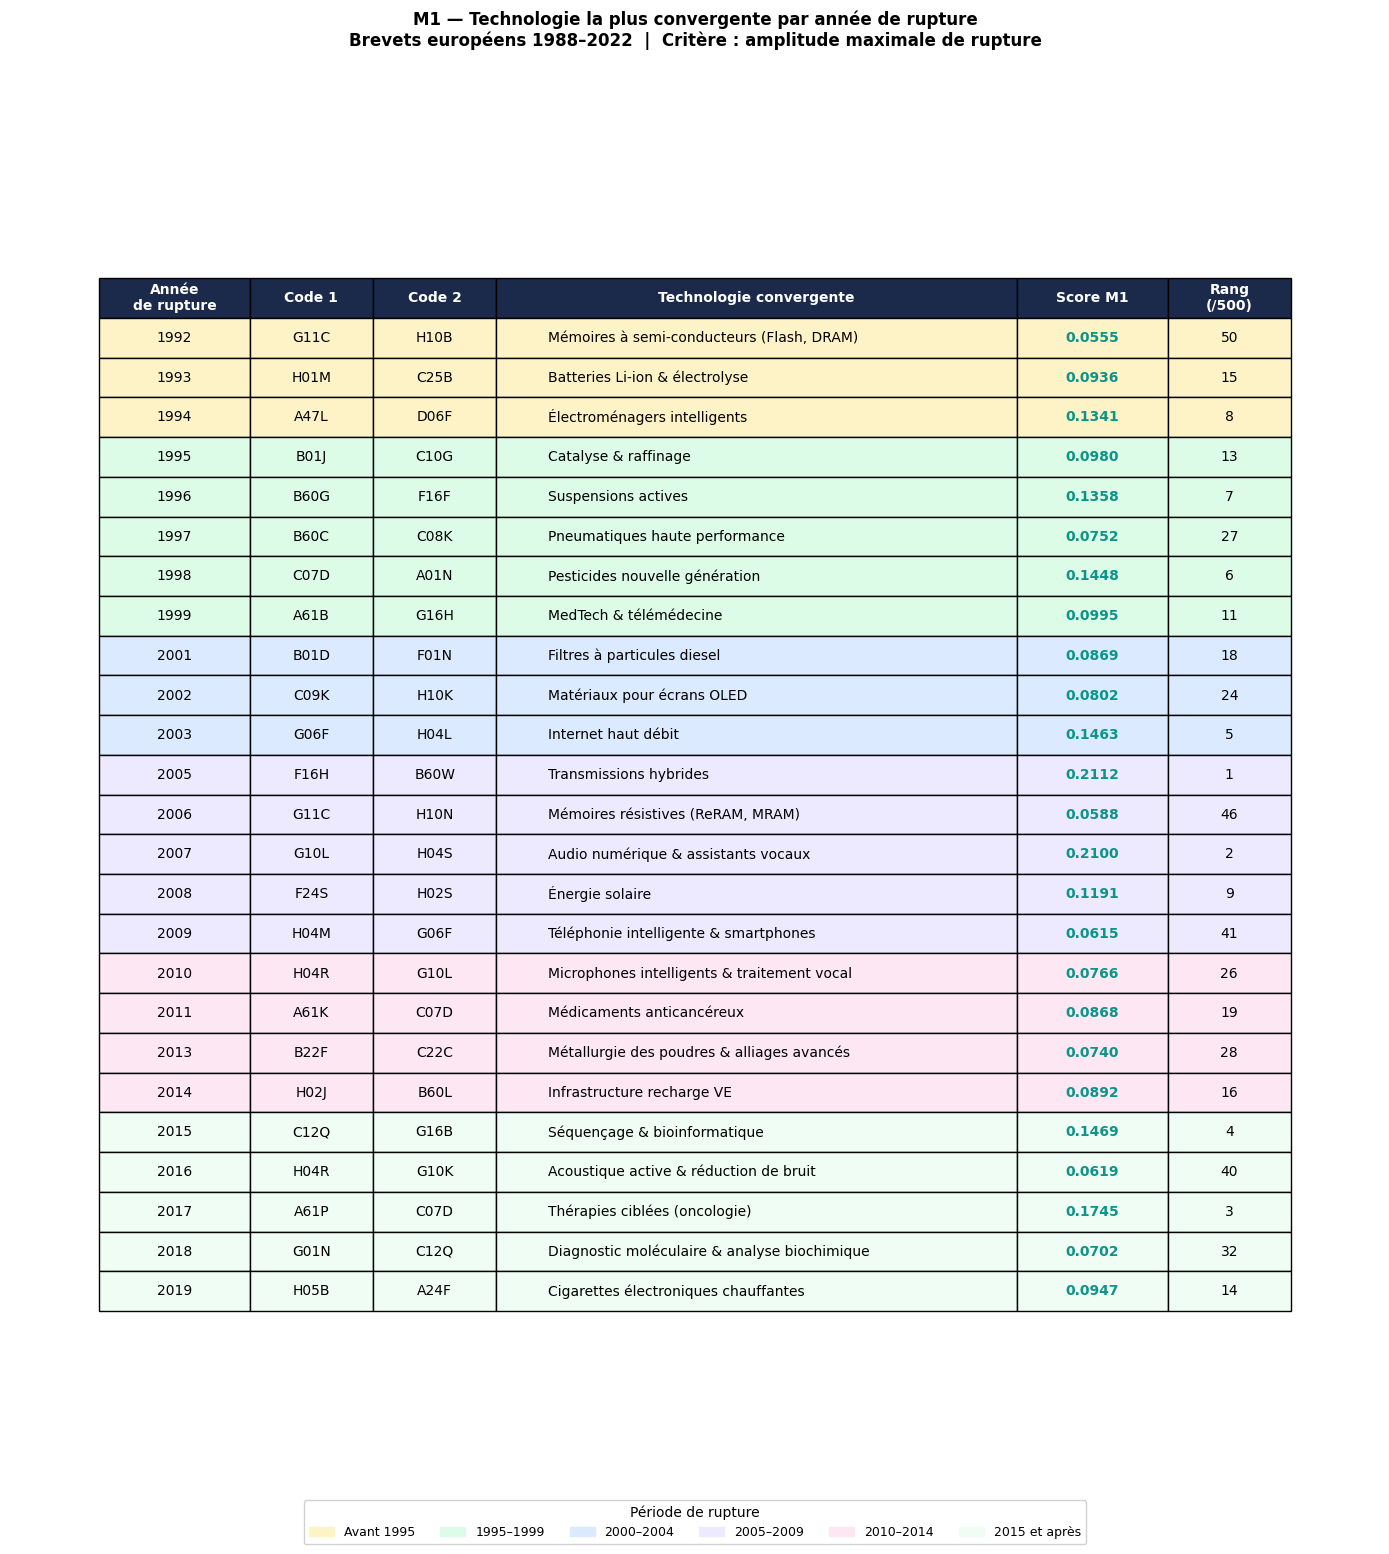

Tableau sauvegardé : m1_tableau_par_annee.png


In [94]:
# ═══════════════════════════════════════════════════════════════════════════
# TABLEAU : TECHNOLOGIE LA PLUS CONVERGENTE PAR ANNÉE DE RUPTURE
# ═══════════════════════════════════════════════════════════════════════════

# ─── Dictionnaire de description des paires CPC ───────────────────────────
# Pour chaque paire du top-20, on donne une description courte
descriptions_paires = {
    ("F16H", "B60W"): "Transmissions hybrides",
    ("G10L", "H04S"): "Audio numérique & assistants vocaux",
    ("A61P", "C07D"): "Thérapies ciblées (oncologie)",
    ("C12Q", "G16B"): "Séquençage & bioinformatique",
    ("G06F", "H04L"): "Internet haut débit",
    ("C07D", "A01N"): "Pesticides nouvelle génération",
    ("B60G", "F16F"): "Suspensions actives",
    ("A47L", "D06F"): "Électroménagers intelligents",
    ("F24S", "H02S"): "Énergie solaire",
    ("H04W", "G08B"): "Alarmes connectées GSM",
    ("A61B", "G16H"): "MedTech & télémédecine",
    ("H04W", "G01S"): "GPS mobile",
    ("B01J", "C10G"): "Catalyse & raffinage",
    ("H05B", "A24F"): "Cigarettes électroniques chauffantes",
    ("H01M", "C25B"): "Batteries Li-ion & électrolyse",
    ("H02J", "B60L"): "Infrastructure recharge VE",
    ("H01Q", "G06K"): "RFID & NFC",
    ("B01D", "F01N"): "Filtres à particules diesel",
    ("A61K", "C07D"): "Médicaments anticancéreux",
    ("C21D", "B21B"): "Aciers haute résistance",
    ("G11C", "H10B"): "Mémoires à semi-conducteurs (Flash, DRAM)",
    ("B60C", "C08K"): "Pneumatiques haute performance",
    ("C09K", "H10K"): "Matériaux pour écrans OLED",
    ("G11C", "H10N"): "Mémoires résistives (ReRAM, MRAM)",
    ("H04M", "G06F"): "Téléphonie intelligente & smartphones",
    ("B22F", "C22C"): "Métallurgie des poudres & alliages avancés",
    ("H04R", "G10L"): "Microphones intelligents & traitement vocal",
    ("H04R", "G10K"): "Acoustique active & réduction de bruit",
    ("G01N", "C12Q"): "Diagnostic moléculaire & analyse biochimique",
}

# ─── Préparer les données ─────────────────────────────────────────────────
# Pour chaque année de rupture, trouver la paire avec le meilleur score

# Prendre le top-50 pour avoir plus de couverture temporelle
top50 = df_m1.head(50).copy()

# Ajouter les descriptions
def get_description(row):
    cle1 = (row["cpc_1"], row["cpc_2"])
    cle2 = (row["cpc_2"], row["cpc_1"])
    return descriptions_paires.get(cle1, descriptions_paires.get(cle2, "—"))

top50["description"] = top50.apply(get_description, axis=1)

# Pour chaque année, garder la paire avec le score le plus élevé
tableau = top50.sort_values("score_ranking_m1", ascending=False)\
               .drop_duplicates(subset="meilleure_rupture")\
               .sort_values("meilleure_rupture")\
               .reset_index(drop=True)

tableau = tableau[[
    "meilleure_rupture", "cpc_1", "cpc_2",
    "description", "score_ranking_m1", "rang_m1"
]]

# ─── Graphique tableau ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, len(tableau) * 0.55 + 1.5))
ax.axis("off")

# Entêtes
entetes = ["Année\nde rupture", "Code 1", "Code 2",
           "Technologie convergente", "Score M1", "Rang\n(/500)"]

# Valeurs
valeurs = []
for _, row in tableau.iterrows():
    valeurs.append([
        str(int(row["meilleure_rupture"])),
        row["cpc_1"],
        row["cpc_2"],
        row["description"],
        f"{row['score_ranking_m1']:.4f}",
        str(int(row["rang_m1"])),
    ])

# ─── Créer le tableau ─────────────────────────────────────────────────────
table = ax.table(
    cellText=valeurs,
    colLabels=entetes,
    cellLoc="center",
    loc="center",
    colWidths=[0.11, 0.09, 0.09, 0.38, 0.11, 0.09]
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.0)

# ─── Style entêtes ────────────────────────────────────────────────────────
for j in range(len(entetes)):
    table[0, j].set_facecolor("#1B2A4A")
    table[0, j].set_text_props(color="white", fontweight="bold", fontsize=10)

# ─── Style lignes ─────────────────────────────────────────────────────────
# Palette de couleurs par décennie
def couleur_decennie(annee):
    annee = int(annee)
    if annee < 1995:  return "#FEF3C7"   # jaune clair — années 1990
    if annee < 2000:  return "#DCFCE7"   # vert clair — fin 1990s
    if annee < 2005:  return "#DBEAFE"   # bleu clair — début 2000s
    if annee < 2010:  return "#EDE9FE"   # violet clair — fin 2000s
    if annee < 2015:  return "#FCE7F3"   # rose clair — début 2010s
    return "#F0FDF4"                      # vert très clair — récent

for i, (_, row) in enumerate(tableau.iterrows(), start=1):
    col_fond = couleur_decennie(row["meilleure_rupture"])
    for j in range(len(entetes)):
        table[i, j].set_facecolor(col_fond)
        # Score en teal et gras
        if j == 4:
            table[i, j].set_text_props(color="#0D9488", fontweight="bold")
        # Description alignée à gauche
        if j == 3:
            table[i, j].set_text_props(ha="left")
            table[i, j]._loc = "left"

# ─── Légende décennies ────────────────────────────────────────────────────
legende_items = [
    mpatches.Patch(color="#FEF3C7", label="Avant 1995"),
    mpatches.Patch(color="#DCFCE7", label="1995–1999"),
    mpatches.Patch(color="#DBEAFE", label="2000–2004"),
    mpatches.Patch(color="#EDE9FE", label="2005–2009"),
    mpatches.Patch(color="#FCE7F3", label="2010–2014"),
    mpatches.Patch(color="#F0FDF4", label="2015 et après"),
]
ax.legend(
    handles=legende_items,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.04),
    ncol=6, fontsize=9, framealpha=0.9,
    title="Période de rupture"
)

# ─── Titre ────────────────────────────────────────────────────────────────
fig.suptitle(
    "M1 — Technologie la plus convergente par année de rupture\n"
    "Brevets européens 1988–2022  |  Critère : amplitude maximale de rupture",
    fontsize=12, fontweight="bold", y=1.01
)

plt.tight_layout()
plt.savefig("m1_tableau_par_annee.png", dpi=150, bbox_inches="tight")
plt.show()
print("Tableau sauvegardé : m1_tableau_par_annee.png")